# Iterative Radiomics-Guided Region Growing Algorithm



## Objective

Implement an iterative region growing algorithm using voxel-based PyRadiomics features on SPECT tumor images.

## Algorithm Overview

1. **Load SPECT DICOM Study**: Import full 3D DICOM series using SimpleITK
2. **Extract & Display Coronal Slice**: Select a specific coronal plane for analysis
3. **Define Working ROI**: Crop the coronal slice to the region of interest
4. **Create Initial Lesion Mask**: Apply intensity thresholding to identify potential lesion
5. **Compute Reference Radiomic Map**: Extract voxel-based Median map inside initial ROI (ROI0)
6. **Establish Statistical Limits**: Use ROI0 distribution as fixed reference (mean ± k*std)
7. **Iterative Region Growing**:
   - Dilate current ROI to generate candidate voxels (corona)
   - Compute voxel-based Median for dilated region
   - Classify each voxel: accept if within statistical bounds
   - Update ROI with accepted voxels
   - Repeat for N iterations
8. **Generate Results & Visualizations**

## Key Implementation Details

- **Radiomic Feature**: `firstorder.Median` (voxel-based)
- **Reference Distribution**: Fixed throughout all iterations
- **PyRadiomics Coordinate Handling**: Automatic reconstruction from bounding-box to full-image coordinates
- **Configurable Parameters**: Threshold percentage, k-value, number of iterations

In [20]:
# ==============================================================================
# 1. IMPORTS & SETUP
# ==============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import SimpleITK as sitk
from pathlib import Path
from scipy.ndimage import binary_dilation
from radiomics import featureextractor
import matplotlib.patches as patches
import pydicom

## Variable parameters

### 1. **Threshold**
### 2. **k_value**
### 3. **Caracteristica radiomica**

In [21]:
# ==================================================================================================
# 2. CONFIGURATION & PARAMETERS
# ==================================================================================================

# Data paths
DATA_DIR = Path("PSMAB37")
SPECT_DIR = DATA_DIR / "SPECT"

# Imaging parameters
CORONAL_SLICE = 137
ROI_CROP = (220, 140)        # (row_start, col_start)

# Thresholding parameters
THRESHOLD_PERCENTILE = 0.65  # Initial ROI = 65% of maximum intensity

# --------------------------------------------------------------------------------------------------
# Radiomic feature
# --------------------------------------------------------------------------------------------------

FEATURE_CLASS = "ngtdm"  # Options: "firstorder", "ngtdm"
FEATURE_NAME = "Coarseness"  # Default feature for the growing experiments
FEATURE_KEY = f"original_{FEATURE_CLASS}_{FEATURE_NAME}"

# --------------------------------------------------------------------------------------------------
# Growing strategy
# --------------------------------------------------------------------------------------------------

MAX_DILATIONS = 15

print("Configuration loaded:")
print(f"  - SPECT directory: {SPECT_DIR}")
print(f"  - Coronal slice: {CORONAL_SLICE}")
print(f"  - ROI crop offset: {ROI_CROP}")
print(f"  - Radiomic feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - Maximum dilations: {MAX_DILATIONS}")

Configuration loaded:
  - SPECT directory: PSMAB37\SPECT
  - Coronal slice: 137
  - ROI crop offset: (220, 140)
  - Radiomic feature: ngtdm.Coarseness
  - Maximum dilations: 15


In [22]:
# ==============================================================================
# PyRadiomics extraction parameters
# ==============================================================================

KERNEL_RADIUS = 1           # Radius for voxel-based extraction
DISTANCES = [1]             # Neighbor distances for texture matrices
WEIGHTING_NORM = None       # None, "manhattan", "euclidean", "infinity"

# Optional preprocessing
NORMALIZE = False
REMOVE_OUTLIERS = None

# Gray level discretization
BIN_WIDTH = 25              # Fixed Bin Size (default)

# Voxel-based extraction
KERNEL_RADIUS = 1           # Default
MASKED_KERNEL = True        # Default

# Texture computation
DISTANCES = [1]             # Default
WEIGHTING_NORM = None       # Default

# Image preprocessing
NORMALIZE = False           # Default
REMOVE_OUTLIERS = None      # Default

# Resampling
RESAMPLED_PIXEL_SPACING = None   # Default
INTERPOLATOR = sitk.sitkBSpline  # Default

## Stage 1: Data Loading & Preparation

In [23]:
from kneed import KneeLocator


def run_region_growing(reference_feature):
    results = []
    history = []
    roi_current = mask0.astype(bool).copy()

# Al principio toda la ROI0 puede crecer
    
    
    stopping_reason = None

    def detect_elbow_threshold(sorted_distances):
        if sorted_distances.size == 0:
            return None, None, "No candidate voxels available."
        if sorted_distances.size == 1:
            return float(sorted_distances[0]), 0, "Single candidate voxel."
        if np.allclose(sorted_distances, sorted_distances[0]):
            return float(sorted_distances[-1]), None, "All candidate distances are identical."

        x_values = np.arange(1, sorted_distances.size + 1)
        locator = KneeLocator(x_values, sorted_distances, curve="convex", direction="increasing")
        if locator.knee is None:
            return None, None, "Elbow could not be detected."

        elbow_index = int(locator.knee) - 1
        elbow_index = max(0, min(elbow_index, sorted_distances.size - 1))
        return float(sorted_distances[elbow_index]), elbow_index, "Elbow detected."

    
    
    from collections import deque

    frontier = deque()

    for r, c in np.argwhere(mask0):
        frontier.append((r, c))


    blocked_edges = set()
    
    for iteration in range(1, MAX_DILATIONS + 1):
        #!--------------------------------------------------------
        candidate_positions = []
        visited = np.zeros_like(roi_current, dtype=bool)

        neighbors = [
    (-1,-1), (-1,0), (-1,1),
    ( 0,-1),         ( 0,1),
    ( 1,-1), (1,0), (1,1)
]

        frontier_positions = list(frontier)

        for r, c in frontier_positions:


            for dr, dc in neighbors:

                rr = r + dr
                cc = c + dc
                
                # ¿Esta conexión ya fue bloqueada?
                if ((r, c), (rr, cc)) in blocked_edges:
                    continue

                if rr < 0 or rr >= roi_current.shape[0]:
                    continue

                if cc < 0 or cc >= roi_current.shape[1]:
                    continue

                if roi_current[rr, cc]:
                    continue

                if visited[rr, cc]:
                    continue

                visited[rr, cc] = True
                candidate_positions.append((rr, cc))

        candidate_positions = np.asarray(candidate_positions)
        corona = visited
        
#!-----------------------------------------------------------
        
        
        if candidate_positions.size == 0:
            stopping_reason = "No candidate voxels available."
            break

        candidate_features = []
        candidate_distances = []
        for row, col in candidate_positions:
            trial_roi = roi_current.copy()
            trial_roi[row, col] = True
            candidate_feature, _ = compute_global_feature(trial_roi)
            candidate_features.append(float(candidate_feature))
            candidate_distances.append(abs(float(candidate_feature) - float(reference_feature)))

        candidate_features = np.asarray(candidate_features, dtype=float)
        candidate_distances = np.asarray(candidate_distances, dtype=float)
        order = np.argsort(candidate_distances)
        ordered_positions = candidate_positions[order]
        ordered_features = candidate_features[order]
        ordered_distances = candidate_distances[order]

        elbow_value, elbow_index, elbow_message = detect_elbow_threshold(ordered_distances)
        if elbow_value is None:
            accepted_order = np.ones_like(ordered_distances, dtype=bool)
            threshold_used = float(ordered_distances[-1])
        else:
            accepted_order = ordered_distances <= elbow_value
            threshold_used = float(elbow_value)

        accepted_positions = ordered_positions[accepted_order]
        rejected_positions = ordered_positions[~accepted_order]
        
        # Las conexiones hacia los rechazados quedan bloqueadas
        for rr, cc in rejected_positions:

            for dr, dc in neighbors:

                r = rr - dr
                c = cc - dc

        # Solo interesa si ese vecino pertenece a la ROI actual
                if (
                    0 <= r < roi_current.shape[0]
                    and 0 <= c < roi_current.shape[1]
                    and roi_current[r, c]
                ):
                    blocked_edges.add(((r, c), (rr, cc)))
            
            
#! -----------------------------------------------------------------------
        accepted_mask = np.zeros_like(roi_current, dtype=bool)
        if accepted_positions.size > 0:
            accepted_mask[accepted_positions[:, 0], 
                          accepted_positions[:, 1]] = True

# ----------------------------------------------------
# NEW: permanently store rejected voxels
# ----------------------------------------------------
        

        


# !----------------------------------------------------



        roi_new = roi_current | accepted_mask
        frontier = deque()

        for r, c in accepted_positions:

    

            frontier.append((r, c))
        
        accepted_count = int(accepted_mask.sum())
        rejected_count = int(corona.sum()) - accepted_count
        size_increase = int(roi_new.sum() - roi_current.sum())
        feature_before, _ = compute_global_feature(roi_current)
        feature_after, _ = compute_global_feature(roi_new)

        results.append({
            "Iteration": iteration,
            "Candidate Voxels": int(corona.sum()),
            "Accepted Voxels": accepted_count,
            "Rejected Voxels": rejected_count,
            "Current ROI Size": int(roi_current.sum()),
            "New ROI Size": int(roi_new.sum()),
            "Cumulative Lesion Size": int(roi_new.sum()),
            "Feature Before": float(feature_before),
            "Feature After": float(feature_after),
            "Feature Change": float(feature_after - feature_before),
            "Elbow Distance": float(threshold_used),
            "Elbow Index": np.nan if elbow_index is None else int(elbow_index + 1),
        })

        history.append({
            "iteration": iteration,
            "roi_current": roi_current.copy(),
        
            "corona": corona.copy(),
            "mask_accepted": accepted_mask.copy(),
            "mask_rejected": np.logical_and(corona, ~accepted_mask),
            "candidate_positions": candidate_positions.copy(),
            "candidate_features": candidate_features.copy(),
            "candidate_distances": candidate_distances.copy(),
            "ordered_positions": ordered_positions.copy(),
            "ordered_features": ordered_features.copy(),
            "ordered_distances": ordered_distances.copy(),
            "accepted_order": accepted_order.copy(),
            "accepted_positions": accepted_positions.copy(),
            "rejected_positions": rejected_positions.copy(),
            "elbow_value": None if elbow_value is None else float(elbow_value),
            "elbow_index": None if elbow_index is None else int(elbow_index),
            "elbow_message": elbow_message,
            "threshold_used": float(threshold_used),
            "feature_before": float(feature_before),
            "feature_after": float(feature_after),
            "roi_after": roi_new.copy(),
            "frontier": list(frontier),
        })

        fig, axes = plt.subplots(2, 2, figsize=(15, 11))

        x_values = np.arange(1, ordered_distances.size + 1)
        axes[0, 0].plot(x_values, ordered_distances, marker='o', linewidth=2, color='steelblue')
        if elbow_value is not None:
            axes[0, 0].axhline(elbow_value, color='crimson', linestyle='--', linewidth=2, label=f'Elbow = {elbow_value:.6f}')
            axes[0, 0].axvline(elbow_index + 1, color='darkgreen', linestyle='--', linewidth=2, label=f'Knee index = {elbow_index + 1}')
        axes[0, 0].set_title(f"Iteration {iteration}: Ordered candidate distances", fontweight='bold')
        axes[0, 0].set_xlabel("Candidate rank")
        axes[0, 0].set_ylabel(f"|{FEATURE_NAME} - reference|")
        axes[0, 0].grid(alpha=0.3)
        axes[0, 0].legend()

        axes[0, 1].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
        axes[0, 1].contour(corona, colors='gold', linewidths=1.8)
        if rejected_positions.size > 0:
            axes[0, 1].scatter(rejected_positions[:, 1], rejected_positions[:, 0], s=22, c='crimson', label='Rejected', alpha=0.8)
        if accepted_positions.size > 0:
            axes[0, 1].scatter(accepted_positions[:, 1], accepted_positions[:, 0], s=28, c='lime', label='Accepted', edgecolors='black', linewidths=0.4)
        axes[0, 1].set_title("Accepted and rejected voxels", fontweight='bold')
        axes[0, 1].axis('off')
        axes[0, 1].legend(loc='upper right')

        bins = min(20, max(5, ordered_distances.size // 2))
        axes[1, 0].hist(ordered_distances, bins=bins, color='skyblue', edgecolor='k', alpha=0.8)
        if elbow_value is not None:
            axes[1, 0].axvline(elbow_value, color='crimson', linestyle='--', linewidth=2, label='Elbow threshold')
            axes[1, 0].legend()
        axes[1, 0].set_title("Candidate distance distribution", fontweight='bold')
        axes[1, 0].set_xlabel(f"|{FEATURE_NAME} - reference|")
        axes[1, 0].set_ylabel("Count")
        axes[1, 0].grid(alpha=0.3)

        axes[1, 1].axis('off')
        summary_text = (
            f"Iteration: {iteration}\n"
            f"Candidates: {int(corona.sum())}\n"
            f"Accepted: {accepted_count}\n"
            f"Rejected: {rejected_count}\n"
            f"ROI size: {int(roi_current.sum())} -> {int(roi_new.sum())}\n"
            f"Threshold: {threshold_used:.6f}\n"
            f"Elbow status: {elbow_message}\n"
            f"Reference feature: {float(reference_feature):.6f}"
        )
        axes[1, 1].text(0.02, 0.98, summary_text, va='top', ha='left', fontsize=11, family='monospace')
        axes[1, 1].set_title("Iteration summary", fontweight='bold')

        plt.tight_layout()
        plt.show()
        plt.close(fig)

        print(
            f"Iter {iteration:2d}: ROI {int(roi_current.sum()):4d} -> {int(roi_new.sum()):4d} | "
            f"Candidates: {int(corona.sum()):4d} | Accepted: {accepted_count:4d} | Rejected: {rejected_count:4d} | "
            f"Threshold: {threshold_used:.6f} | {elbow_message}"
        )

        roi_current = roi_new

    if stopping_reason is None:
        stopping_reason = "Maximum number of dilations reached."

    roi_final = roi_current.copy()
    return roi_final, results, history, stopping_reason


print("✓ Growing algorithm defined")

✓ Growing algorithm defined


In [24]:
# Load SPECT DICOM series
reader = sitk.ImageSeriesReader()
files = reader.GetGDCMSeriesFileNames(str(SPECT_DIR))
reader.SetFileNames(files)
spect_img = reader.Execute()# este es el objeto de imagen de SPECT en SimpleITK

spect_array = sitk.GetArrayFromImage(spect_img)# este es la imagen de SPECT en un array de numpy

print(f" SPECT series loaded")
print(f"  - Shape: {spect_array.shape}")#Formato: (z, y, x) para imágenes 3D
print(f"  - Size: {spect_img.GetSize()}")#Formato: (x, y, z) para imágenes 3D
print(f"  - Spacing: {spect_img.GetSpacing()}") #Devuelve el tamaño físico de cada voxel en milímetros (x_spacing, y_spacing, z_spacing)
print(f"  - Range: [{spect_array.min():.2f}, {spect_array.max():.2f}]") #Muestra los valores mínimo y máximo de intensidad de la imagen.

 SPECT series loaded
  - Shape: (299, 256, 256)
  - Size: (256, 256, 299)
  - Spacing: (2.734375, 2.734375, 3.270000022529765)
  - Range: [0.00, 52344.30]


 Coronal slice extracted and processed
  - Coronal slice index: 137
  - Full coronal shape: (299, 256)
  - Working ROI shape: (79, 116)
  - ROI intensity range: [0.00, 19446.12]


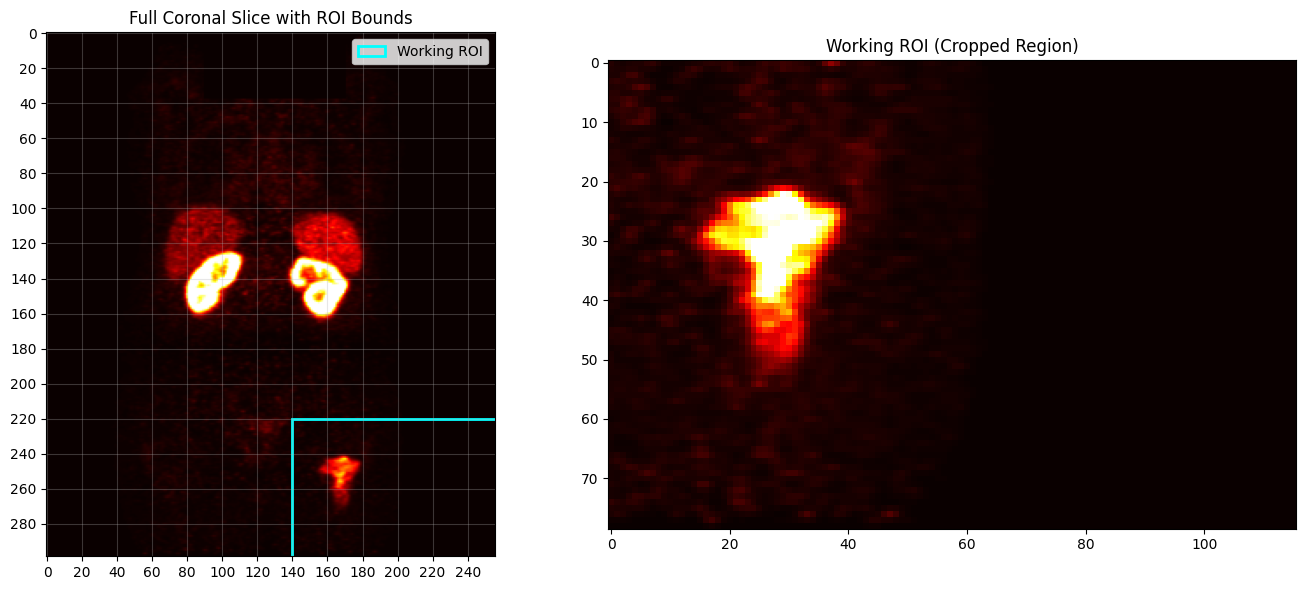

In [25]:
# Extract and display coronal slice
coronal_raw = spect_array[:, CORONAL_SLICE, :]#
coronal_vis = np.fliplr(np.rot90(coronal_raw, 2))# SE ROTAN 180 GRADOS Y SE VOLTEA HORIZONTALMENTE PARA QUE LA IMAGEN CORONAL SE VISUALICE CORRECTAMENTE


# Crop to working region
roi_img = coronal_vis[ROI_CROP[0]:, ROI_CROP[1]:]# se recorta la imagen coronal para obtener la región de interés (ROI) a partir de las coordenadas especificadas en ROI_CROP

print(f" Coronal slice extracted and processed")
print(f"  - Coronal slice index: {CORONAL_SLICE}")
print(f"  - Full coronal shape: {coronal_vis.shape}")
print(f"  - Working ROI shape: {roi_img.shape}")
print(f"  - ROI intensity range: [{roi_img.min():.2f}, {roi_img.max():.2f}]")

# Visualize working ROI
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Full coronal image
axes[0].imshow(
    coronal_vis,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(coronal_vis, 99)
)

# Coordinate grid
axes[0].set_xticks(np.arange(0, coronal_vis.shape[1], 20))
axes[0].set_yticks(np.arange(0, coronal_vis.shape[0], 20))
axes[0].grid(True, alpha=0.3)

# ROI rectangle
roi_rect = patches.Rectangle(
    (ROI_CROP[1], ROI_CROP[0]),               # (x, y)
    coronal_vis.shape[1] - ROI_CROP[1],      # width
    coronal_vis.shape[0] - ROI_CROP[0],      # height
    linewidth=2,
    edgecolor="cyan",
    facecolor="none",
    label="Working ROI"
)

axes[0].add_patch(roi_rect)

axes[0].set_title("Full Coronal Slice with ROI Bounds")
axes[0].legend()

# Cropped ROI
axes[1].imshow(
    roi_img,
    cmap="hot",
    vmin=0,
    vmax=np.percentile(roi_img, 99)
)

axes[1].set_title("Working ROI (Cropped Region)")
axes[1].axis("on")

plt.tight_layout()
plt.show()

### ____________________________________________________________________________-

✓ Manual segmentation loaded
  - Segmented voxels (3D): 4828
  - Segmented pixels in ROI: 318


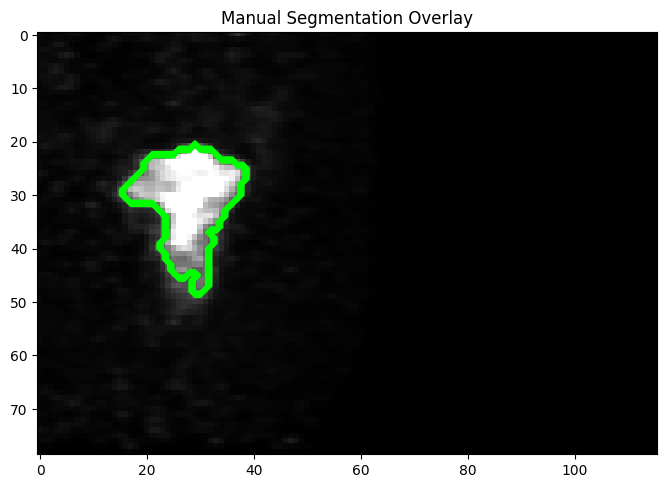

In [26]:
# ==============================================================================
# ! Stage 1.5: Load Manual Segmentation (DICOM SEG)
# ==============================================================================

SEG_PATH = DATA_DIR / "SEGMENTATIONS" / "1-1.dcm"

def load_manual_segmentation(
    seg_path,
    spect_dir,
    spect_array,
    coronal_slice,
    roi_crop
):
    """
    Load DICOM SEG, reconstruct full 3D segmentation volume,
    extract the same coronal plane used by the algorithm,
    and apply identical visualization transforms and ROI crop.
    """

    # Load SEG object
    seg = pydicom.dcmread(str(seg_path))
    seg_array = seg.pixel_array.astype(np.uint8)

    # Build UID -> slice index map from SPECT series
    spect_files = sorted(Path(spect_dir).glob("*.dcm"))

    uid_to_slice = {}

    for idx, f in enumerate(spect_files):

        ds = pydicom.dcmread(
            str(f),
            stop_before_pixels=True
        )

        uid_to_slice[ds.SOPInstanceUID] = idx

    # Determine which SPECT slice corresponds to each SEG frame
    seg_slices = []

    for frame in seg.PerFrameFunctionalGroupsSequence:

        uid = (
            frame.DerivationImageSequence[0]
            .SourceImageSequence[0]
            .ReferencedSOPInstanceUID
        )

        if uid in uid_to_slice:
            seg_slices.append(uid_to_slice[uid])

    # Reconstruct full 3D segmentation volume
    manual_mask_3d = np.zeros_like(
        spect_array,
        dtype=np.uint8
    )

    for frame_idx, spect_idx in enumerate(seg_slices):
        manual_mask_3d[spect_idx] = seg_array[frame_idx]

    # Extract same coronal plane
    manual_coronal_raw = manual_mask_3d[:, coronal_slice, :]

    # Apply same visualization orientation
    manual_coronal_vis = np.flipud(
        np.fliplr(
            np.rot90(manual_coronal_raw, 2)
        )
    )

    # Apply same ROI crop
    manual_mask_roi = manual_coronal_vis[
        roi_crop[0]:,
        roi_crop[1]:
    ]

    return (
        manual_mask_3d,
        manual_coronal_vis,
        manual_mask_roi
    )

# Load manual segmentation
manual_mask_3d, manual_coronal_vis, manual_mask_roi = (
    load_manual_segmentation(
        SEG_PATH,
        SPECT_DIR,
        spect_array,
        CORONAL_SLICE,
        ROI_CROP
    )
)

print("✓ Manual segmentation loaded")
print(f"  - Segmented voxels (3D): {manual_mask_3d.sum()}")
print(f"  - Segmented pixels in ROI: {manual_mask_roi.sum()}")

# Visual verification

plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img, 99)
)

plt.contour(
    manual_mask_roi,
    colors="lime",
    linewidths=2
)

plt.title("Manual Segmentation Overlay")
plt.show()

### _____________________________________________________________________________________________

## Stage 2: Initial Lesion Mask (ROI0)

 Initial mask (ROI0) created
  - Threshold: 65% of max = 12639.98
  - Mask size: 76 voxels


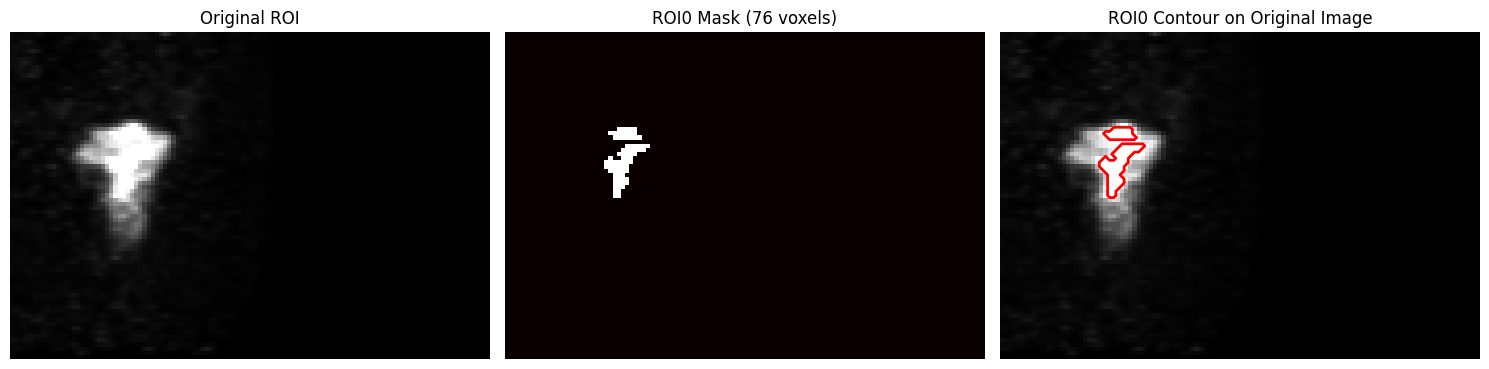

In [27]:
# Create initial lesion mask (ROI0)
threshold = THRESHOLD_PERCENTILE * roi_img.max() 
mask0 = roi_img > threshold # todo voxel con intensidad mayor al umbral se considera parte de la lesión y se marca como True en la máscara binaria mask0

print(f" Initial mask (ROI0) created")
print(f"  - Threshold: {THRESHOLD_PERCENTILE * 100:.0f}% of max = {threshold:.2f}")
print(f"  - Mask size: {mask0.sum()} voxels")

# Visualize initial mask
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].set_title("Original ROI")
axes[0].axis('off')

axes[1].imshow(mask0, cmap="hot")
axes[1].set_title(f"ROI0 Mask ({mask0.sum()} voxels)")
axes[1].axis('off')

axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='r', linewidths=2)
axes[2].set_title("ROI0 Contour on Original Image")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Stage 3: PyRadiomics Setup & Utility Functions

## Initialize PyRadiomics feature extractor
extractor = featureextractor.RadiomicsFeatureExtractor()  # Crear una instancia del extractor de PyRadiomics con la configuración por defecto
extractor.disableAllFeatures()  # Desactivar todas las características para evitar cálculos innecesarios
extractor.enableFeaturesByName(**{FEATURE_CLASS: [FEATURE_NAME]})  # Habilitar únicamente la característica especificada (ej. firstorder: Median)

print(f"✓ PyRadiomics extractor initialized") 
print(f"  - Feature: {FEATURE_CLASS}.{FEATURE_NAME}")  
print(f"  - Voxel-based extraction enabled") 

In [28]:
# ==============================================================================
# Initialize PyRadiomics feature extractor
# ==============================================================================

settings = {
    "binWidth": BIN_WIDTH,
    "kernelRadius": KERNEL_RADIUS,
    "distances": DISTANCES,
    "weightingNorm": WEIGHTING_NORM,
    "normalize": NORMALIZE
}

if REMOVE_OUTLIERS is not None:
    settings["removeOutliers"] = REMOVE_OUTLIERS

extractor = featureextractor.RadiomicsFeatureExtractor(**settings)

# Enable only the desired feature
extractor.disableAllFeatures()
extractor.enableFeaturesByName(
    **{FEATURE_CLASS: [FEATURE_NAME]}
)

print("✓ PyRadiomics extractor initialized")
print(f"  - Feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - Voxel-based extraction enabled")
print("  - Extraction settings:")
print(f"      binWidth        = {BIN_WIDTH}")
print(f"      kernelRadius    = {KERNEL_RADIUS}")
print(f"      distances       = {DISTANCES}")
print(f"      weightingNorm   = {WEIGHTING_NORM}")
print(f"      normalize       = {NORMALIZE}")
print(f"      removeOutliers  = {REMOVE_OUTLIERS}")


✓ PyRadiomics extractor initialized
  - Feature: ngtdm.Coarseness
  - Voxel-based extraction enabled
  - Extraction settings:
      binWidth        = 25
      kernelRadius    = 1
      distances       = [1]
      weightingNorm   = None
      normalize       = False
      removeOutliers  = None


In [29]:
def reconstruct_voxel_map(result_dict, reference_shape, feature_key):
    """
    result_dict: diccionario de resultados de PyRadiomics que contiene la característica extraída y la bounding box
    reference_shape: la forma de la imagen original
    feature_key: clave de la característica en result_dict (ej. "original_firstorder_M
    
    Tomar el mapa radiomico (que viene en bounding box) y colocarlo de nuevo en 
    la imagen original. ME DA UN ARRAY CON el mapa radiomico voxel-based reubicado en el sistema original de la imagen (80×60), lo que 
    no esta en el bounding box esta llenos de ceros sin filtrar aun con la mascara
    """
    bbox_key = "diagnostics_Mask-original_BoundingBox"  # variable donde PyRadiomics guarda la bounding box
    if bbox_key not in result_dict:  # verifica que la bounding box esté presente en el resultado
        raise ValueError(f"Bounding box not found in result. Available keys: {result_dict.keys()}")  # lanza error si falta
    
    bbox = result_dict[bbox_key]  # extrae la tupla bounding box
    x, y, z, sx, sy, sz = bbox  # desempaqueta las coordenadas y tamaños del bounding box
    
    if feature_key not in result_dict:  # comprueba que la clave de la característica exista en el resultado
        raise ValueError(
            f"Feature key '{feature_key}' not found in result. Available keys: {list(result_dict.keys())}"
        )  # lanza error si la característica no está presente
    feature_img = result_dict[feature_key]  # obtiene la imagen SimpleITK correspondiente a la característica
    median_map = sitk.GetArrayFromImage(feature_img)[0]  # convierte la imagen a numpy y toma la primera (única) z-slice
    
    full_map = np.zeros(reference_shape, dtype=float)  # inicializa el mapa completo con ceros (float)
    
    h, w = median_map.shape  # obtiene alto y ancho del mapa dentro del bounding box
    x0 = x - 1  # convierte la coordenada x de 1-based (PyRadiomics) a 0-based (numpy)
    y0 = y - 1  # convierte la coordenada y de 1-based a 0-based
    
    full_map[
        y0:y0 + h,
        x0:x0 + w
    ] = median_map  # inserta el mapa extraído en la posición correspondiente del mapa completo
    
    return full_map, (x0, y0, h, w)  # devuelve el mapa reconstruido y la información de bounding box ajustada

print("✓ Utility function 'reconstruct_voxel_map' defined")  # confirma que la función ha sido definida


✓ Utility function 'reconstruct_voxel_map' defined


## Stage 4: Reference Distribution (ROI0 Voxel-Based Statistics)

✓ Reference feature computed from ROI0
  - Feature: original_ngtdm_Coarseness
  - Reference value: 0.016172
  - ROI0 voxels: 76


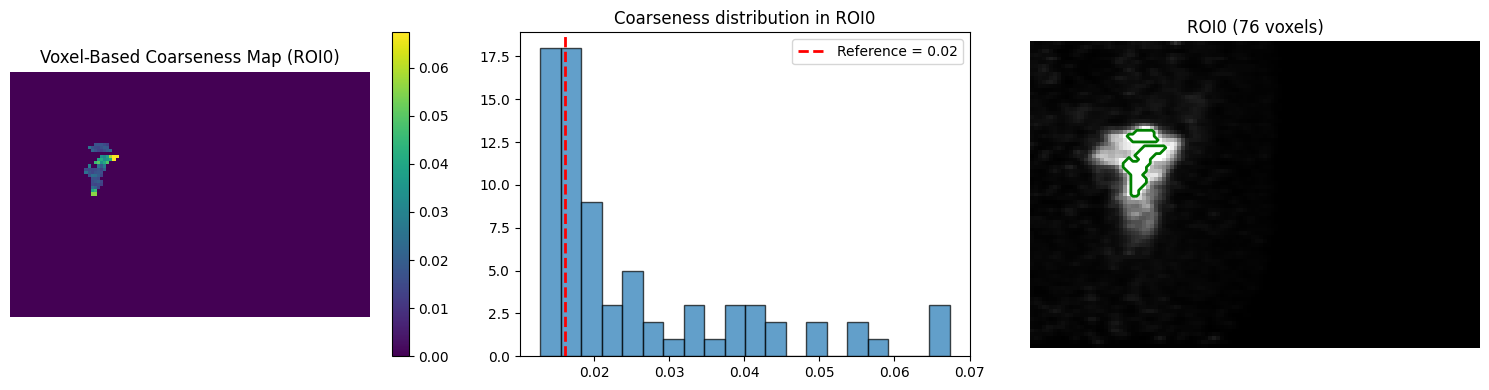

In [30]:
# Extract ROI0 global reference feature and voxel-based map for visualization
img_3d = roi_img[np.newaxis, :, :].astype(np.float32)
mask0_3d = mask0[np.newaxis, :, :].astype(np.uint8)

sitk_img = sitk.GetImageFromArray(img_3d)
sitk_mask0 = sitk.GetImageFromArray(mask0_3d)

reference_result = extractor.execute(sitk_img, sitk_mask0, voxelBased=False)
reference_feature = float(reference_result[FEATURE_KEY])

# Keep the voxel-based map for inspection and plotting
result_roi0 = extractor.execute(sitk_img, sitk_mask0, voxelBased=True)
voxel_map_roi0, bbox_info = reconstruct_voxel_map(result_roi0, roi_img.shape, FEATURE_KEY)
vals_roi0 = voxel_map_roi0[mask0]

print(f"✓ Reference feature computed from ROI0")
print(f"  - Feature: {FEATURE_KEY}")
print(f"  - Reference value: {reference_feature:.6f}")
print(f"  - ROI0 voxels: {mask0.sum()}")

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].imshow(voxel_map_roi0, cmap="viridis")
axes[0].set_title(f"Voxel-Based {FEATURE_NAME} Map (ROI0)")
axes[0].colorbar = plt.colorbar(axes[0].images[0], ax=axes[0])
axes[0].axis('off')

axes[1].hist(vals_roi0, bins=20, edgecolor='k', alpha=0.7)
axes[1].axvline(reference_feature, color='r', linestyle='--', linewidth=2, label=f"Reference = {reference_feature:.2f}")
axes[1].set_title(f"{FEATURE_NAME} distribution in ROI0")
axes[1].legend()

axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='g', linewidths=2)
axes[2].set_title(f"ROI0 ({mask0.sum()} voxels)")
axes[2].axis('off')

plt.tight_layout()
plt.show()

## Stage 5: Iterative Region Growing

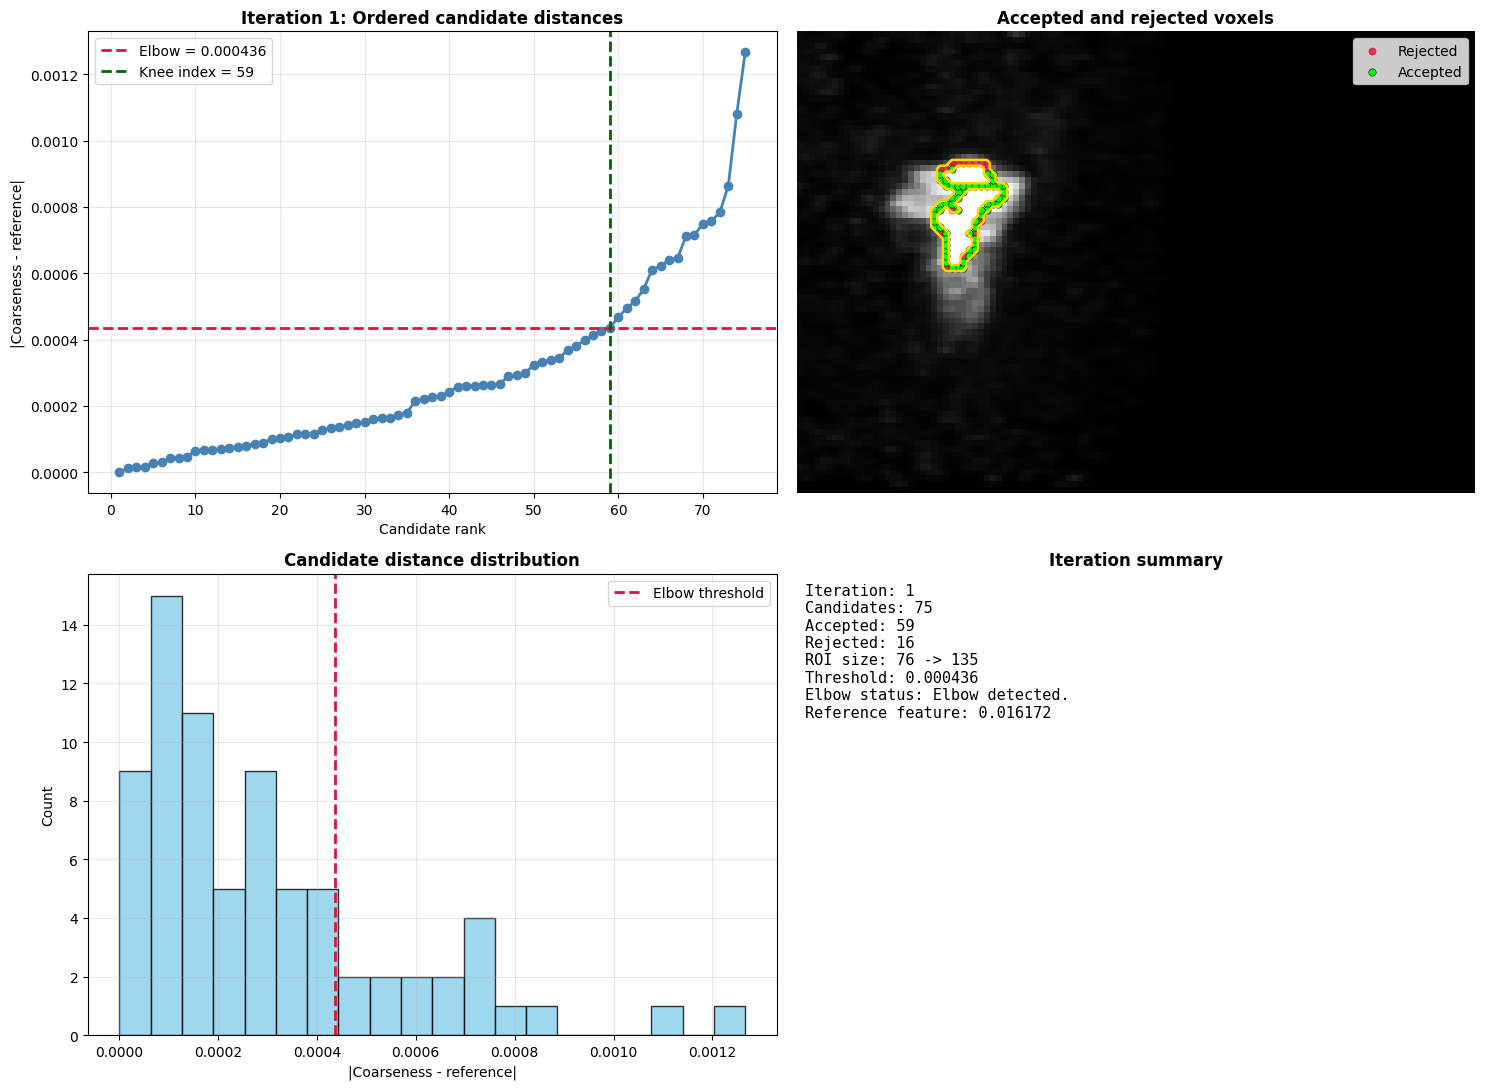

Iter  1: ROI   76 ->  135 | Candidates:   75 | Accepted:   59 | Rejected:   16 | Threshold: 0.000436 | Elbow detected.


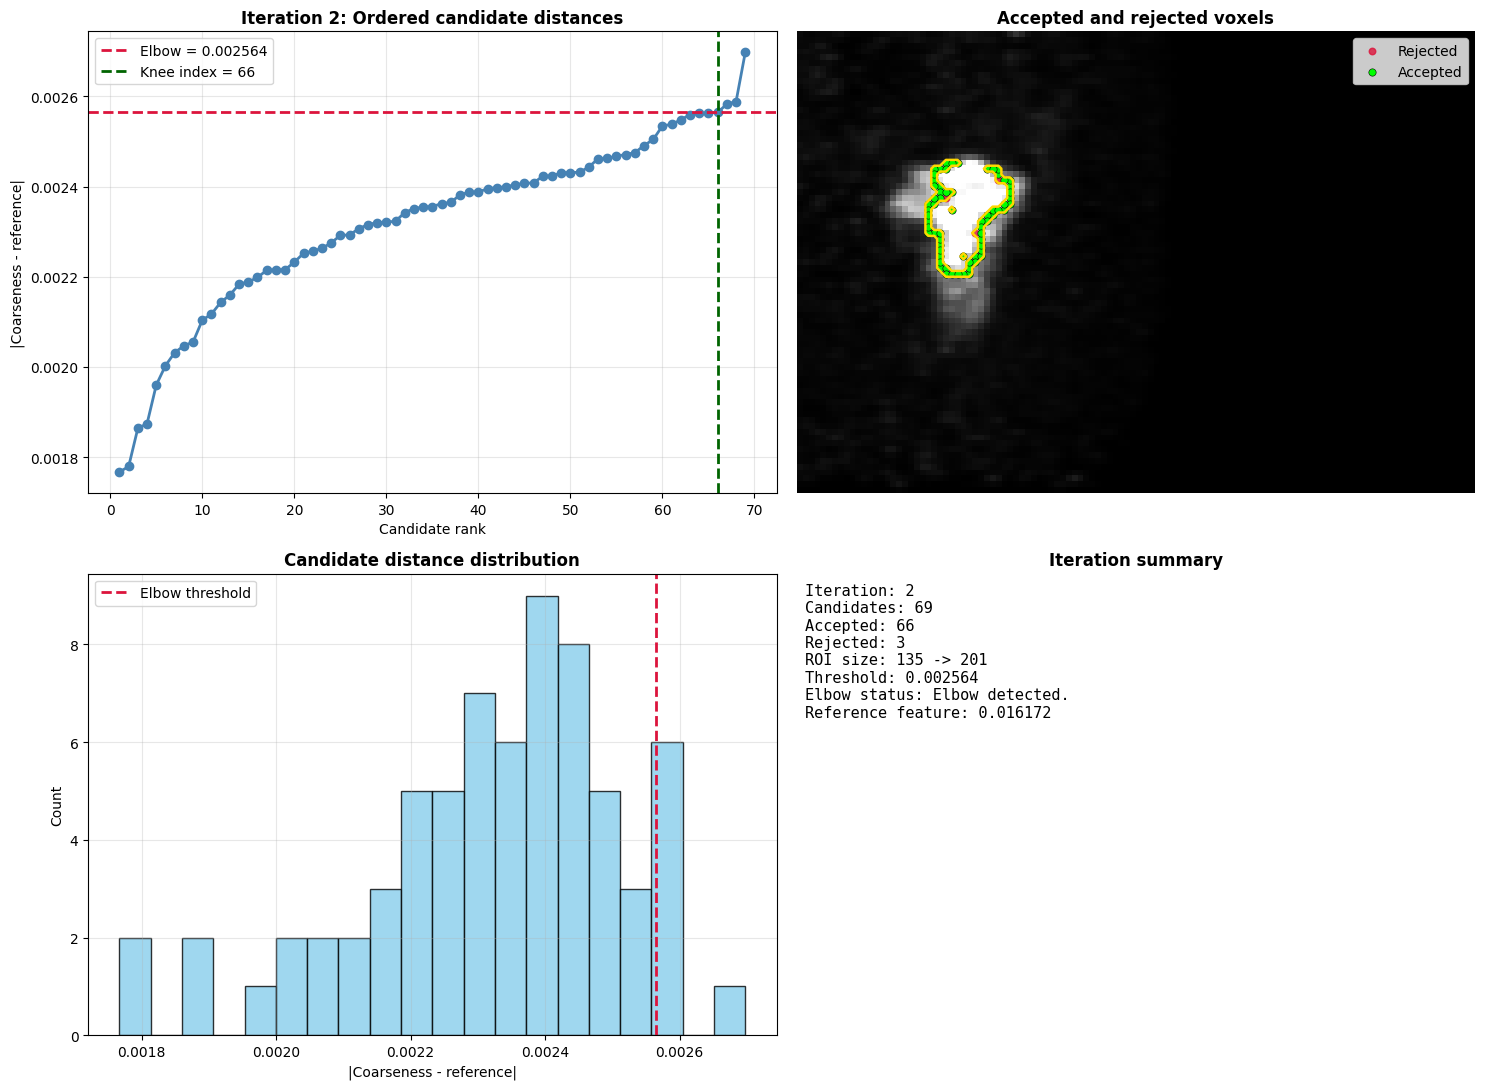

Iter  2: ROI  135 ->  201 | Candidates:   69 | Accepted:   66 | Rejected:    3 | Threshold: 0.002564 | Elbow detected.


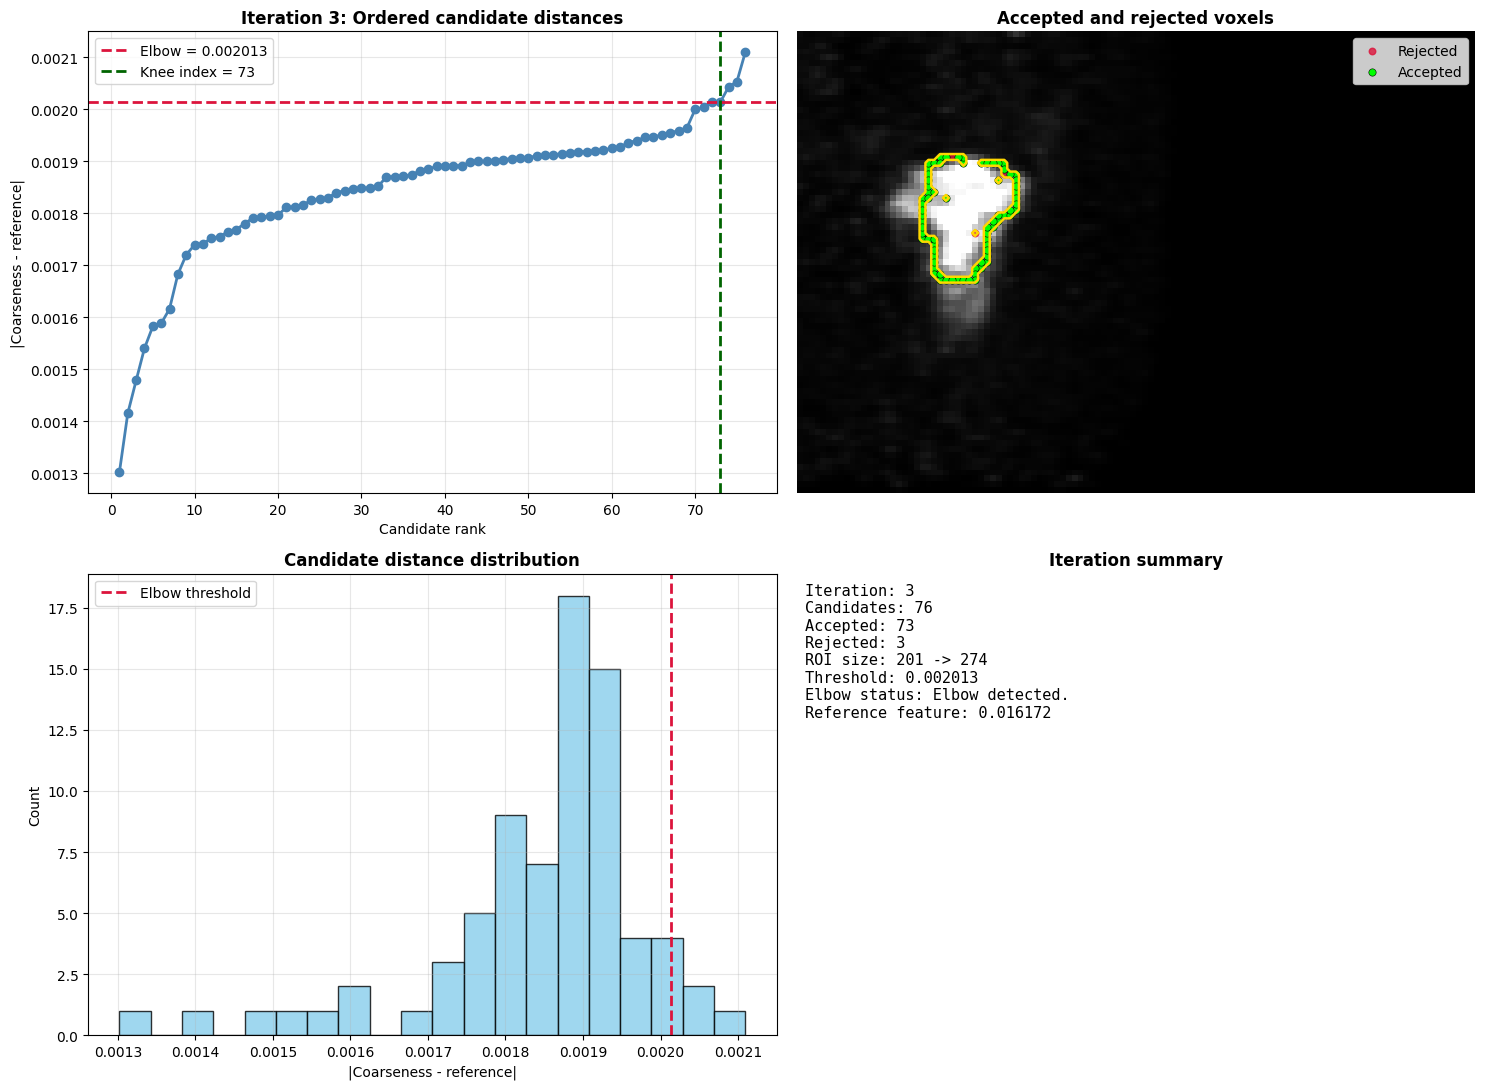

Iter  3: ROI  201 ->  274 | Candidates:   76 | Accepted:   73 | Rejected:    3 | Threshold: 0.002013 | Elbow detected.


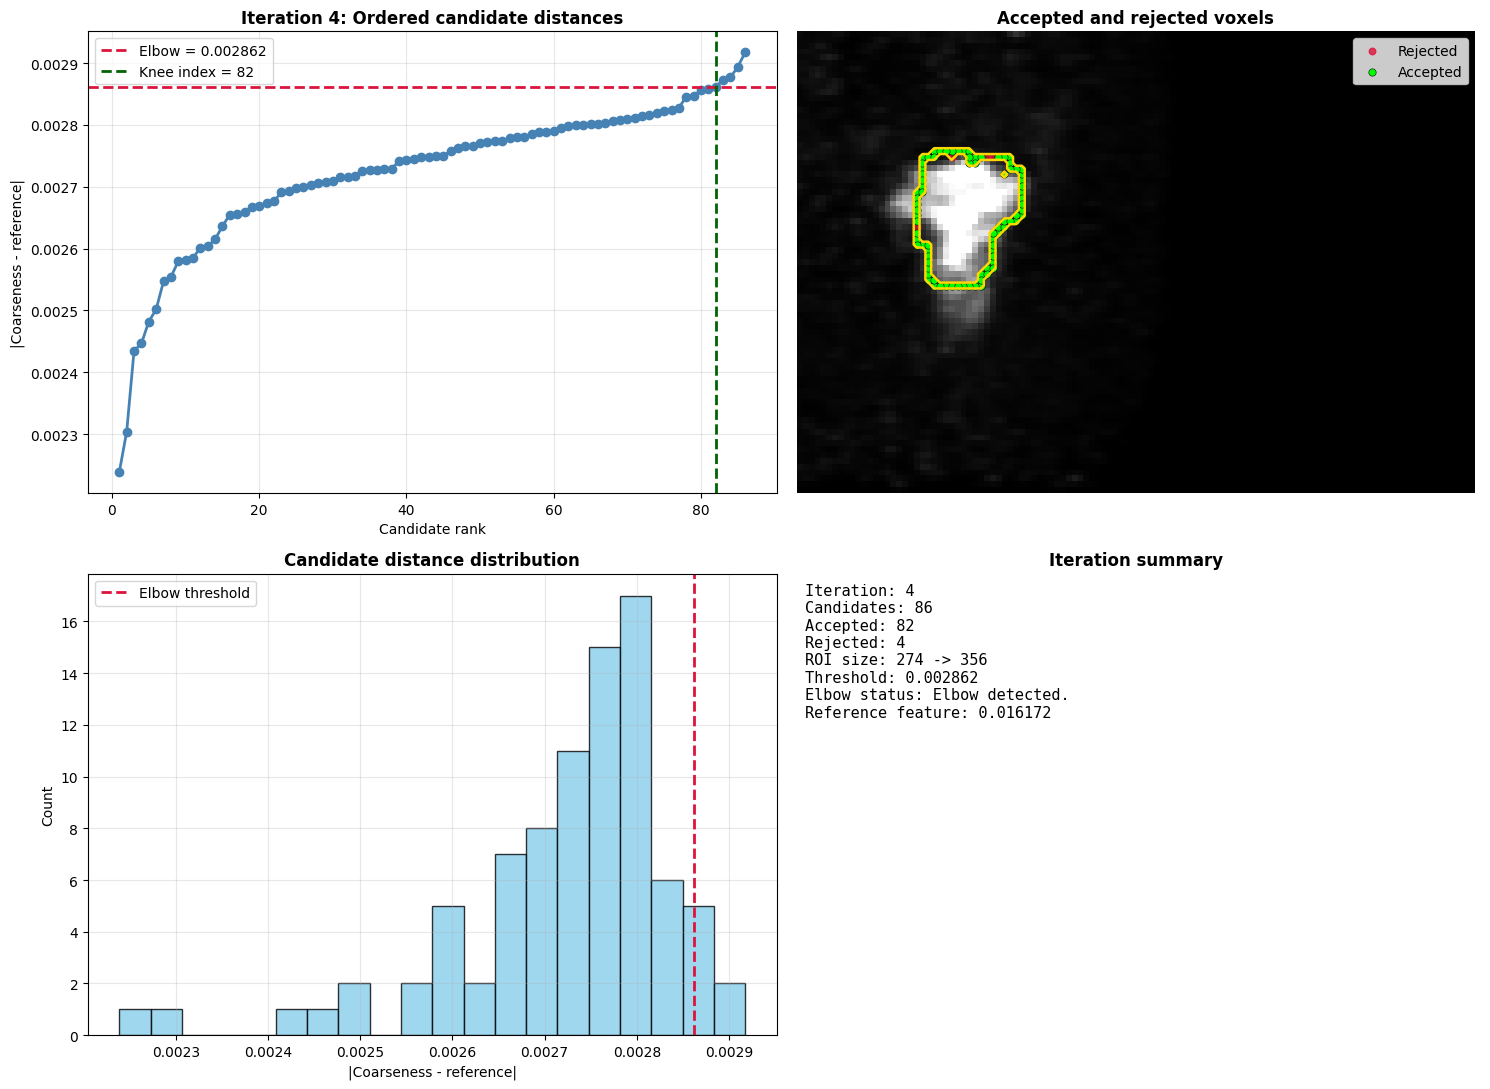

Iter  4: ROI  274 ->  356 | Candidates:   86 | Accepted:   82 | Rejected:    4 | Threshold: 0.002862 | Elbow detected.


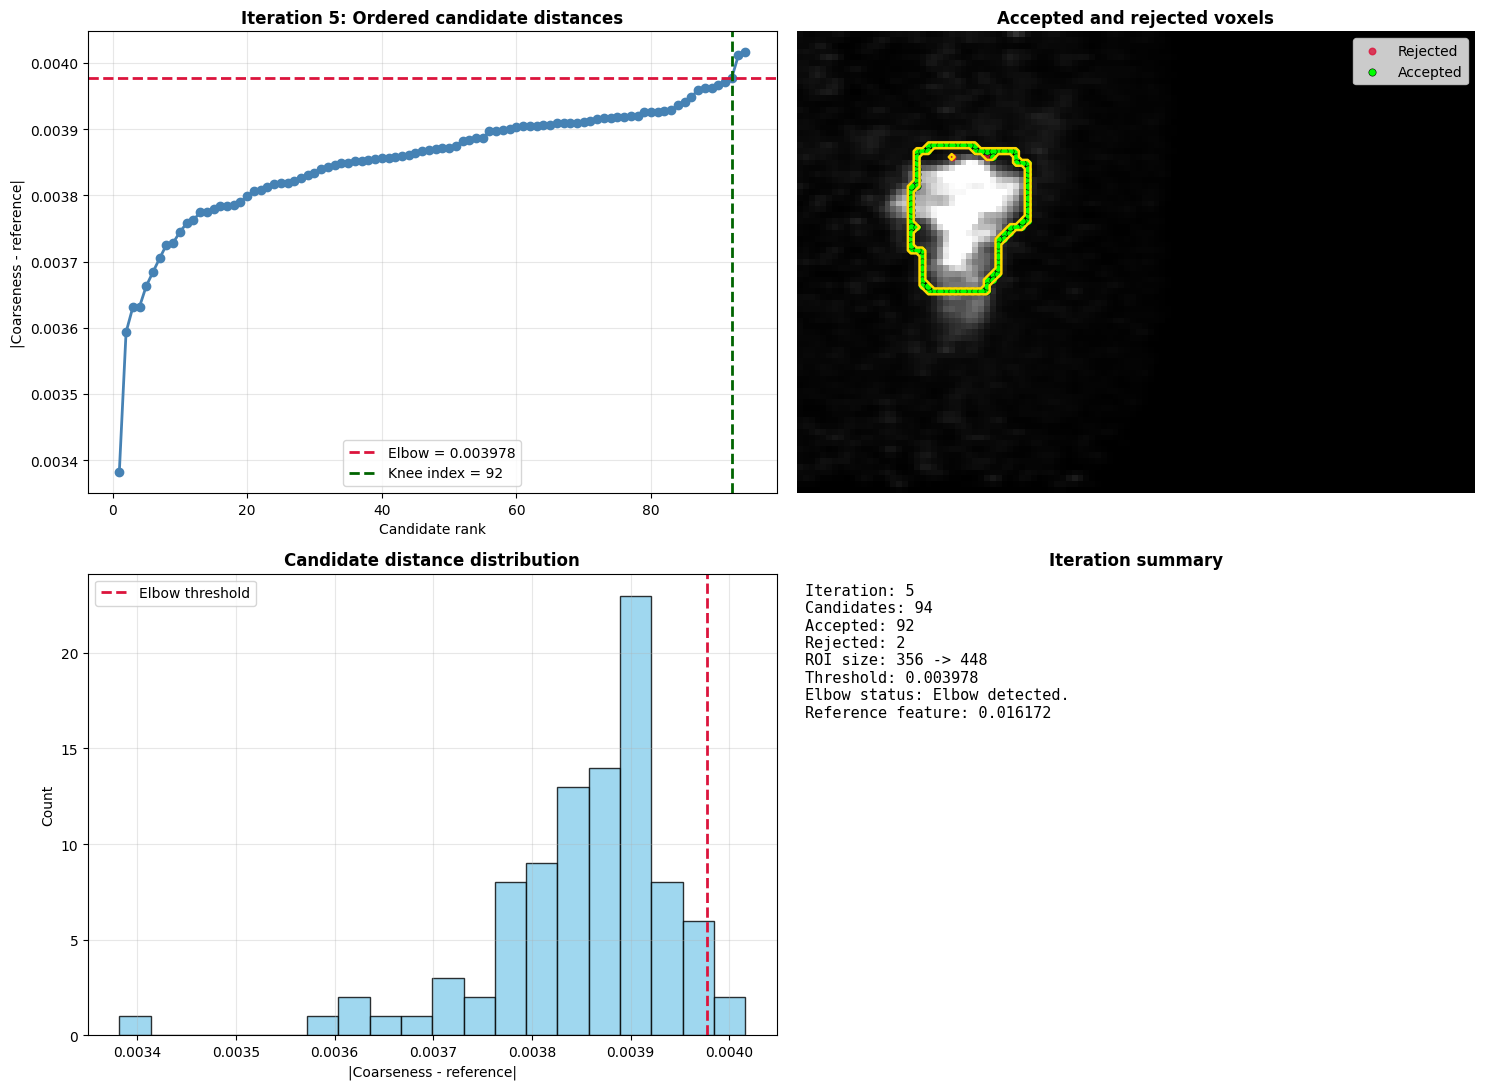

Iter  5: ROI  356 ->  448 | Candidates:   94 | Accepted:   92 | Rejected:    2 | Threshold: 0.003978 | Elbow detected.


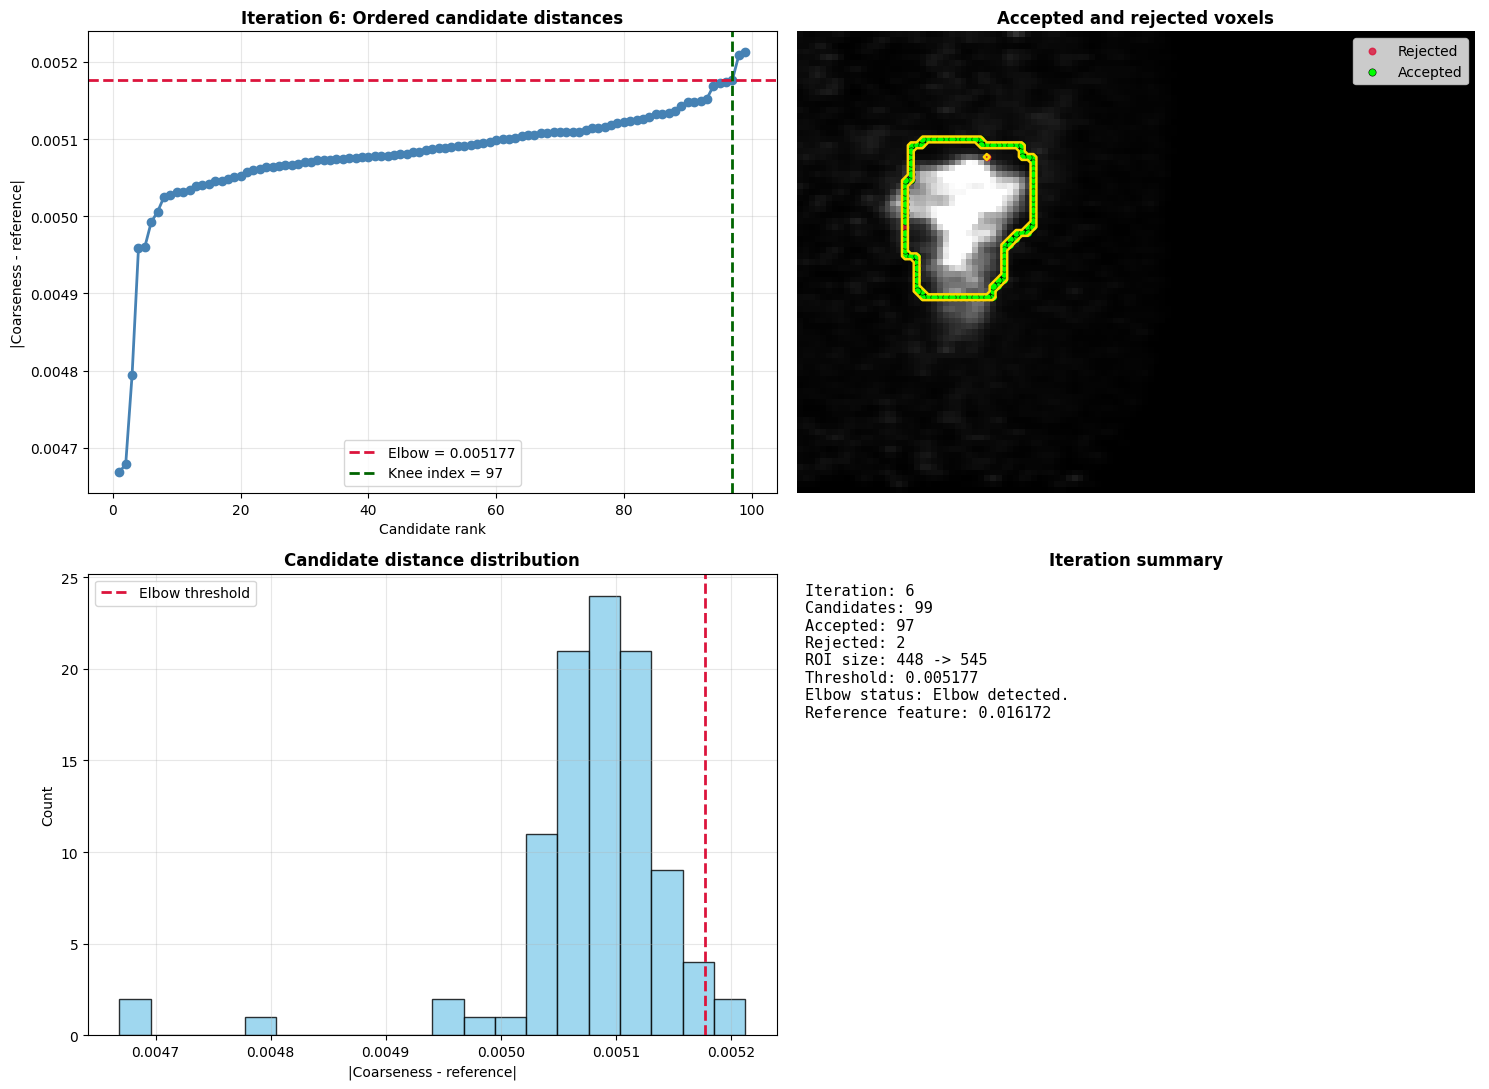

Iter  6: ROI  448 ->  545 | Candidates:   99 | Accepted:   97 | Rejected:    2 | Threshold: 0.005177 | Elbow detected.


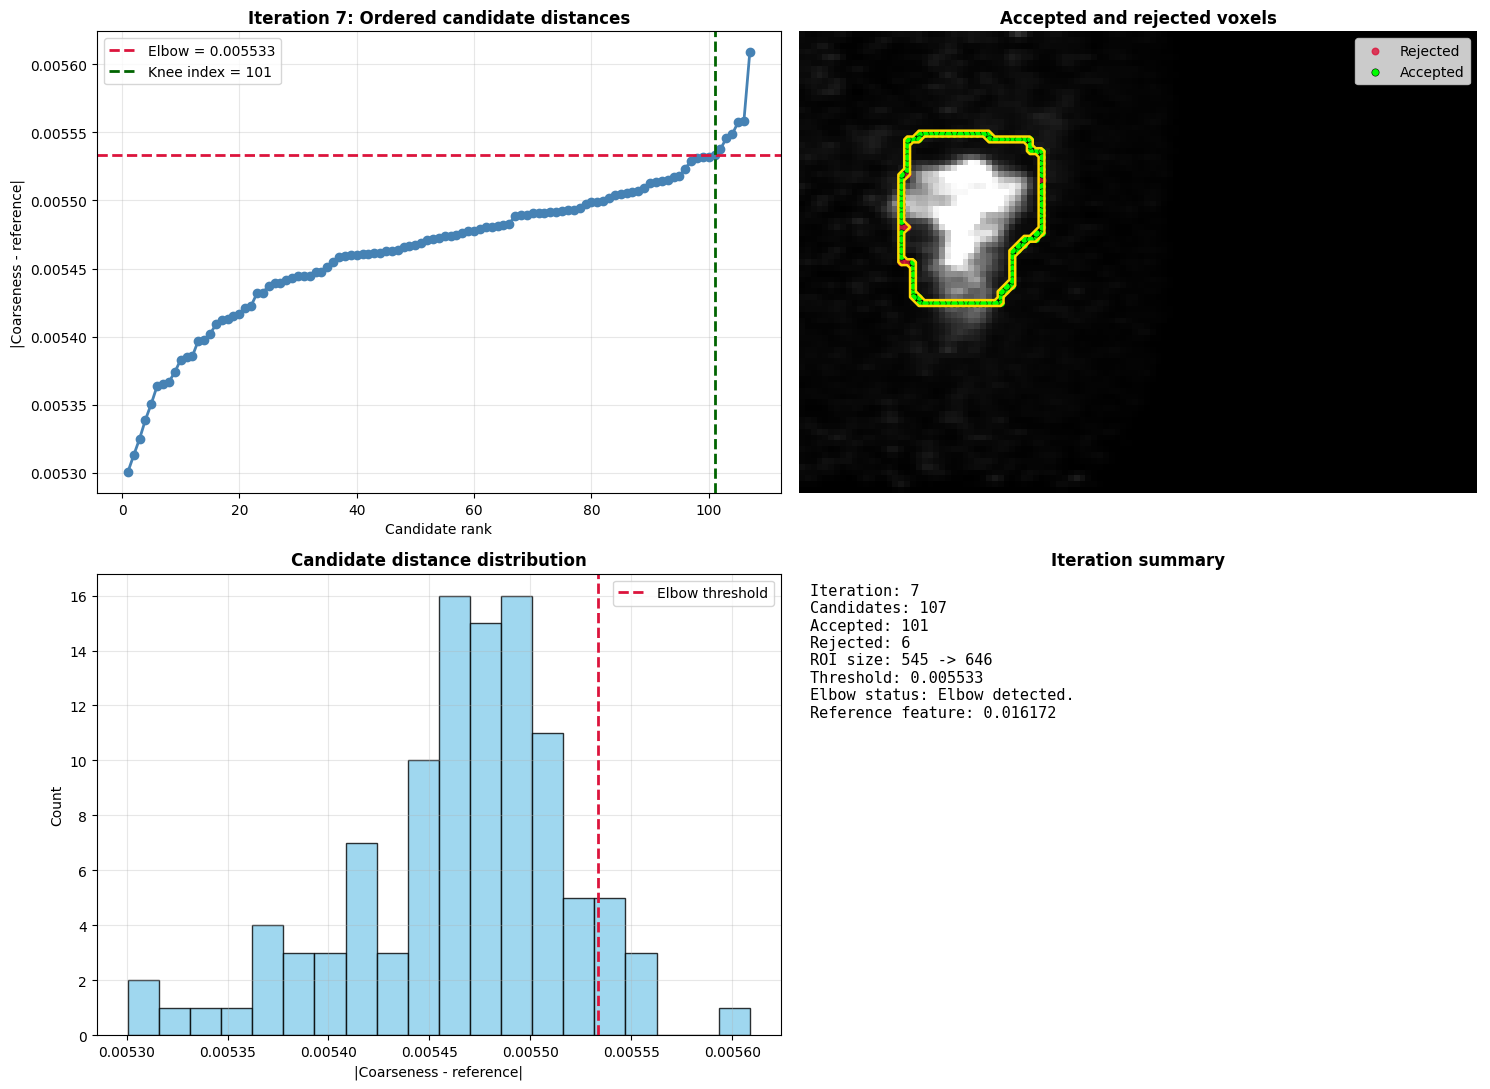

Iter  7: ROI  545 ->  646 | Candidates:  107 | Accepted:  101 | Rejected:    6 | Threshold: 0.005533 | Elbow detected.


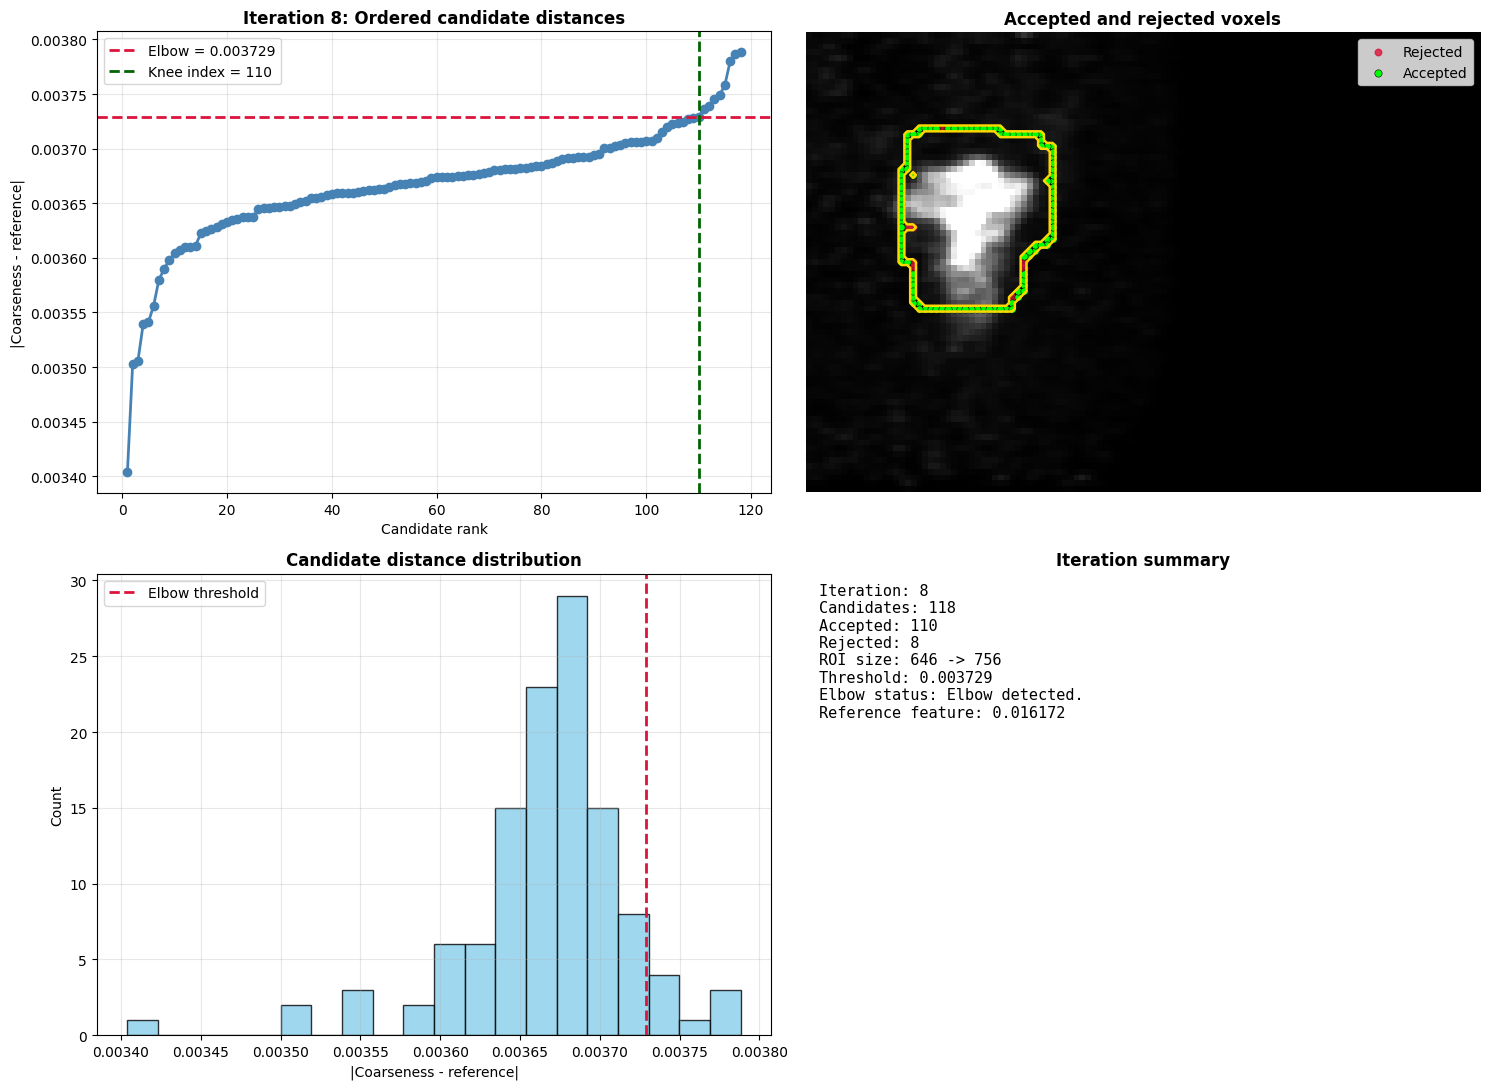

Iter  8: ROI  646 ->  756 | Candidates:  118 | Accepted:  110 | Rejected:    8 | Threshold: 0.003729 | Elbow detected.


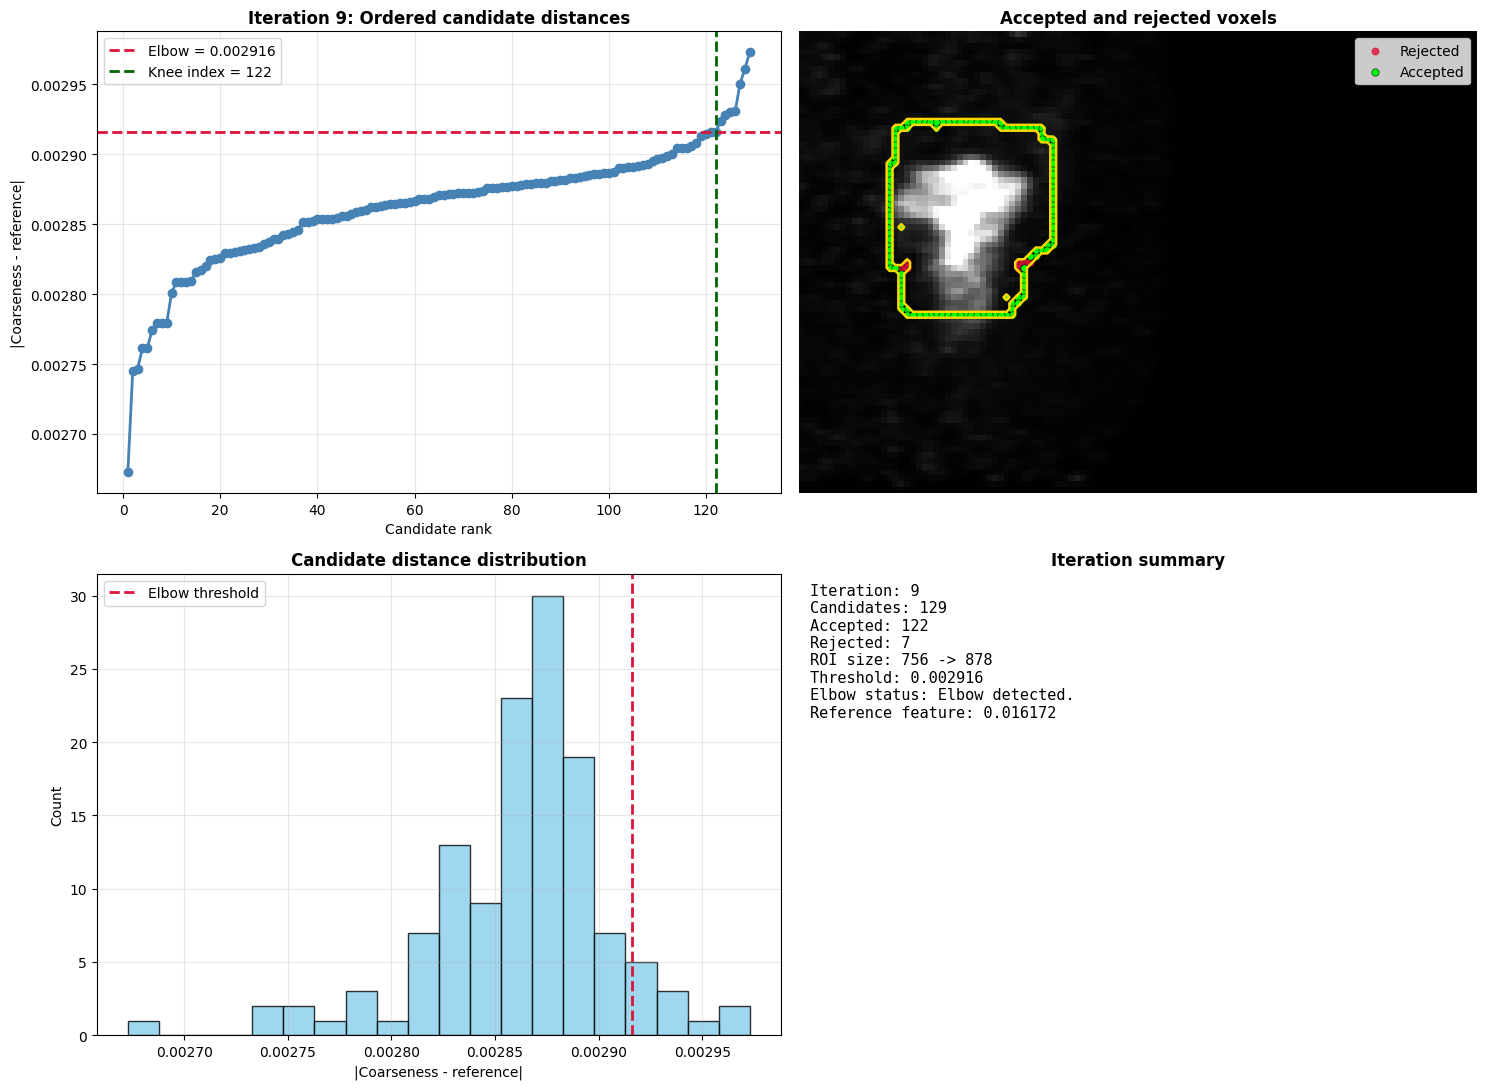

Iter  9: ROI  756 ->  878 | Candidates:  129 | Accepted:  122 | Rejected:    7 | Threshold: 0.002916 | Elbow detected.


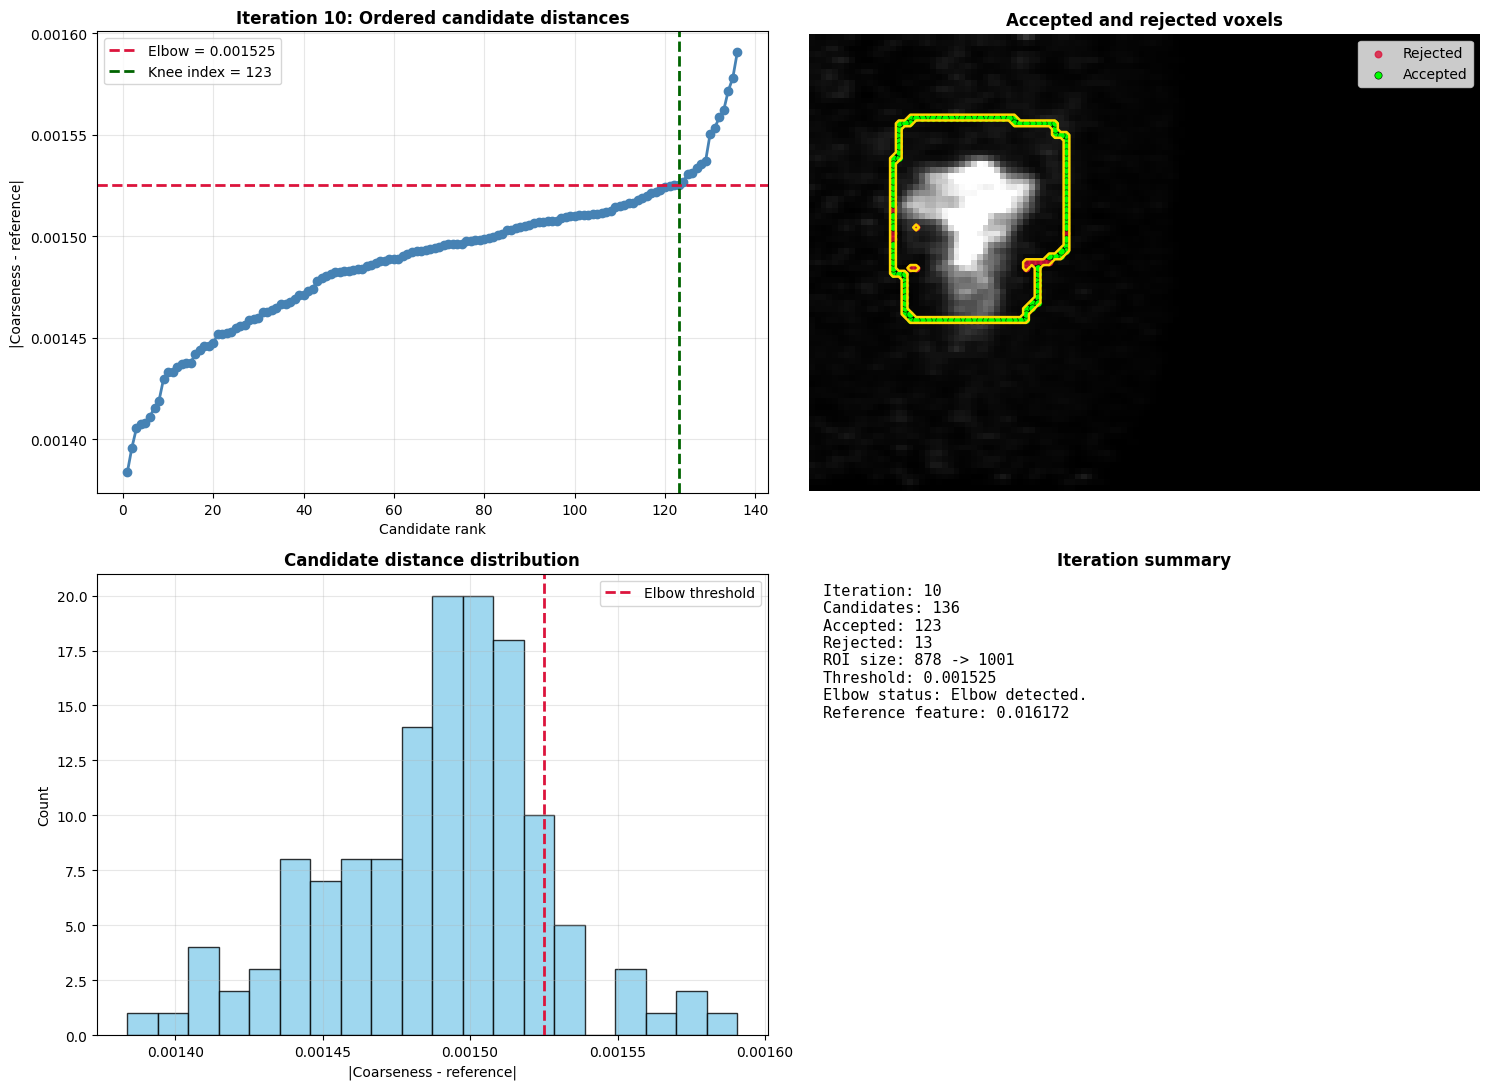

Iter 10: ROI  878 -> 1001 | Candidates:  136 | Accepted:  123 | Rejected:   13 | Threshold: 0.001525 | Elbow detected.


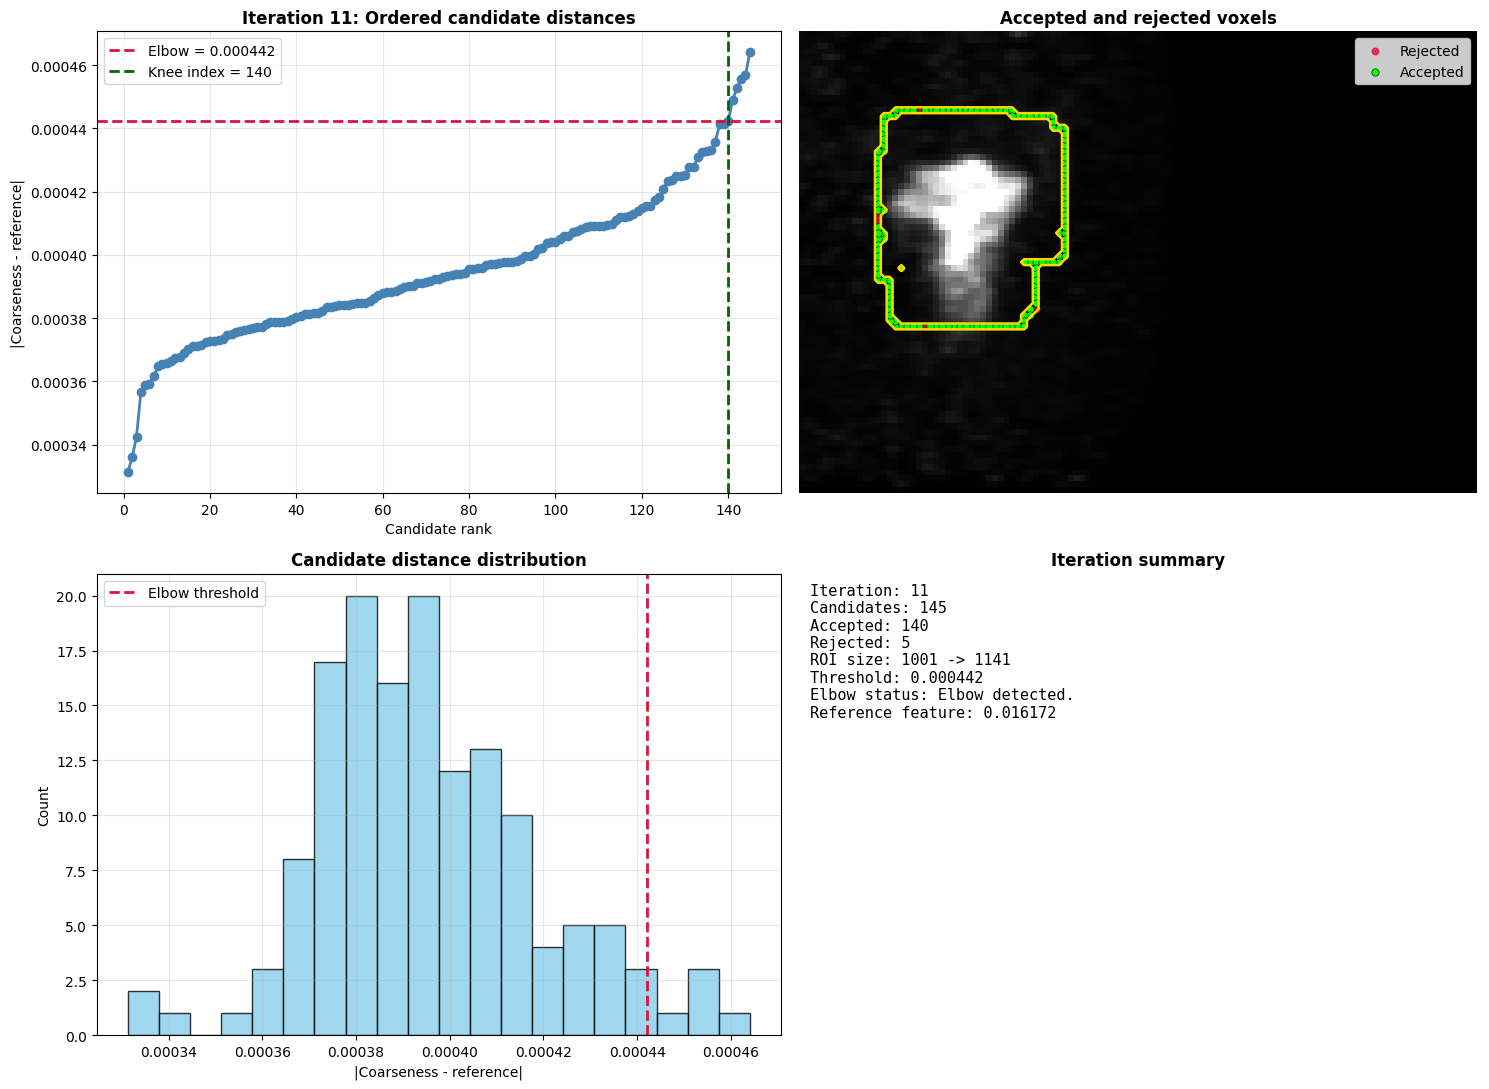

Iter 11: ROI 1001 -> 1141 | Candidates:  145 | Accepted:  140 | Rejected:    5 | Threshold: 0.000442 | Elbow detected.


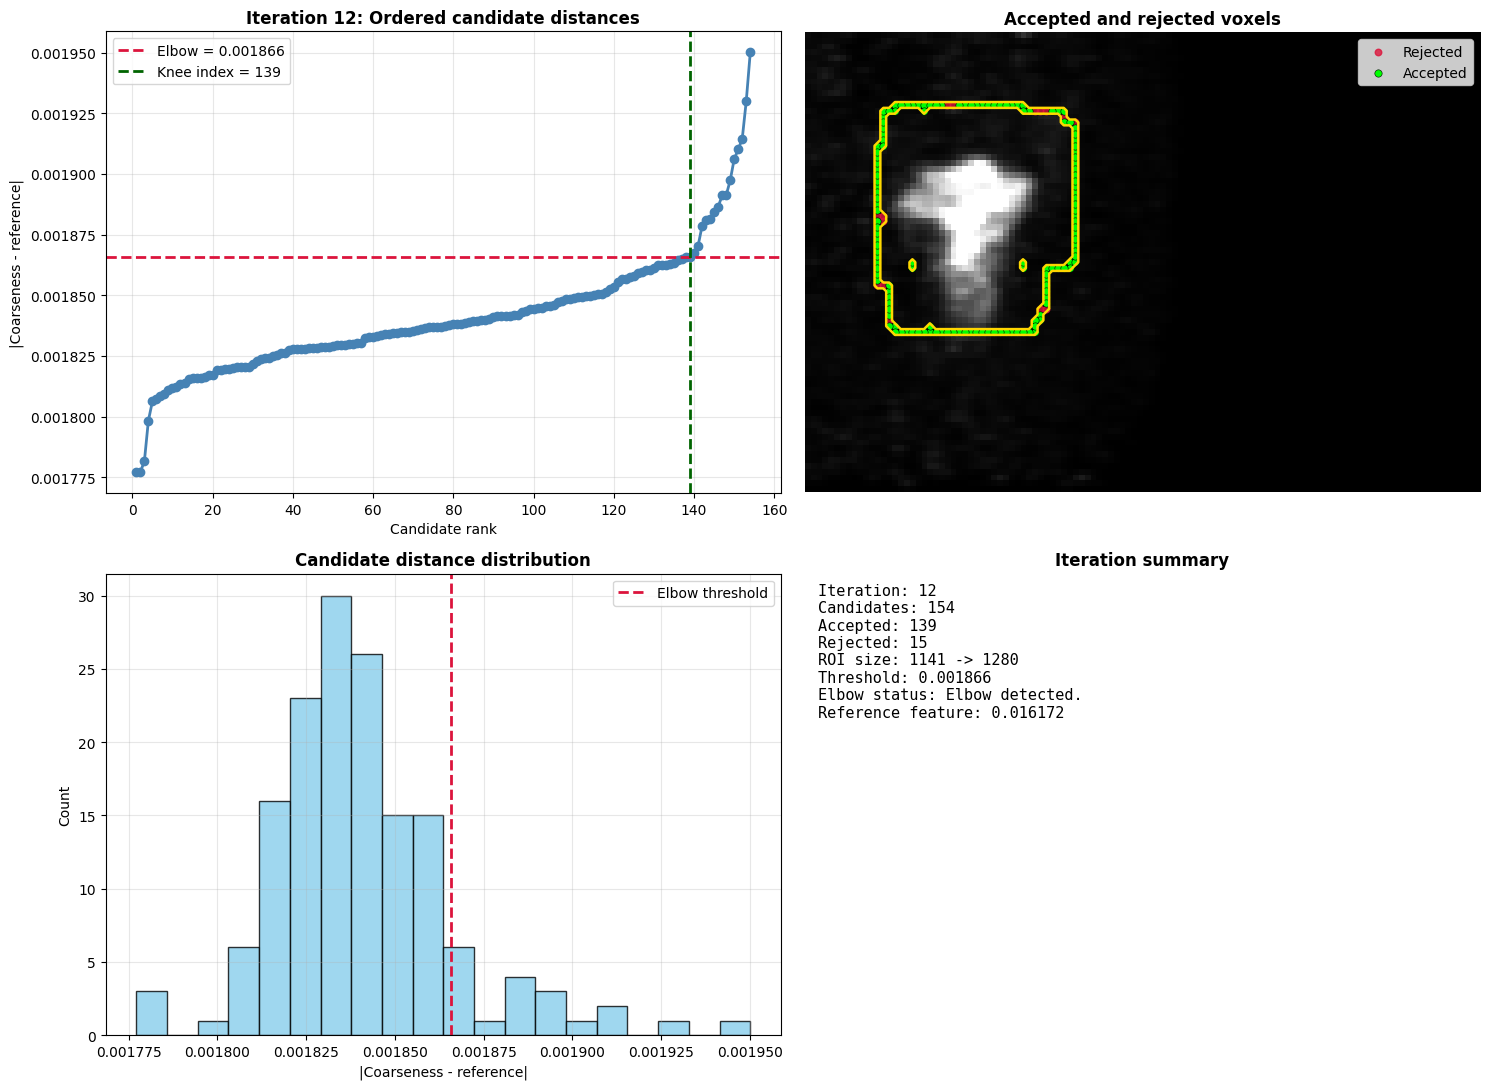

Iter 12: ROI 1141 -> 1280 | Candidates:  154 | Accepted:  139 | Rejected:   15 | Threshold: 0.001866 | Elbow detected.


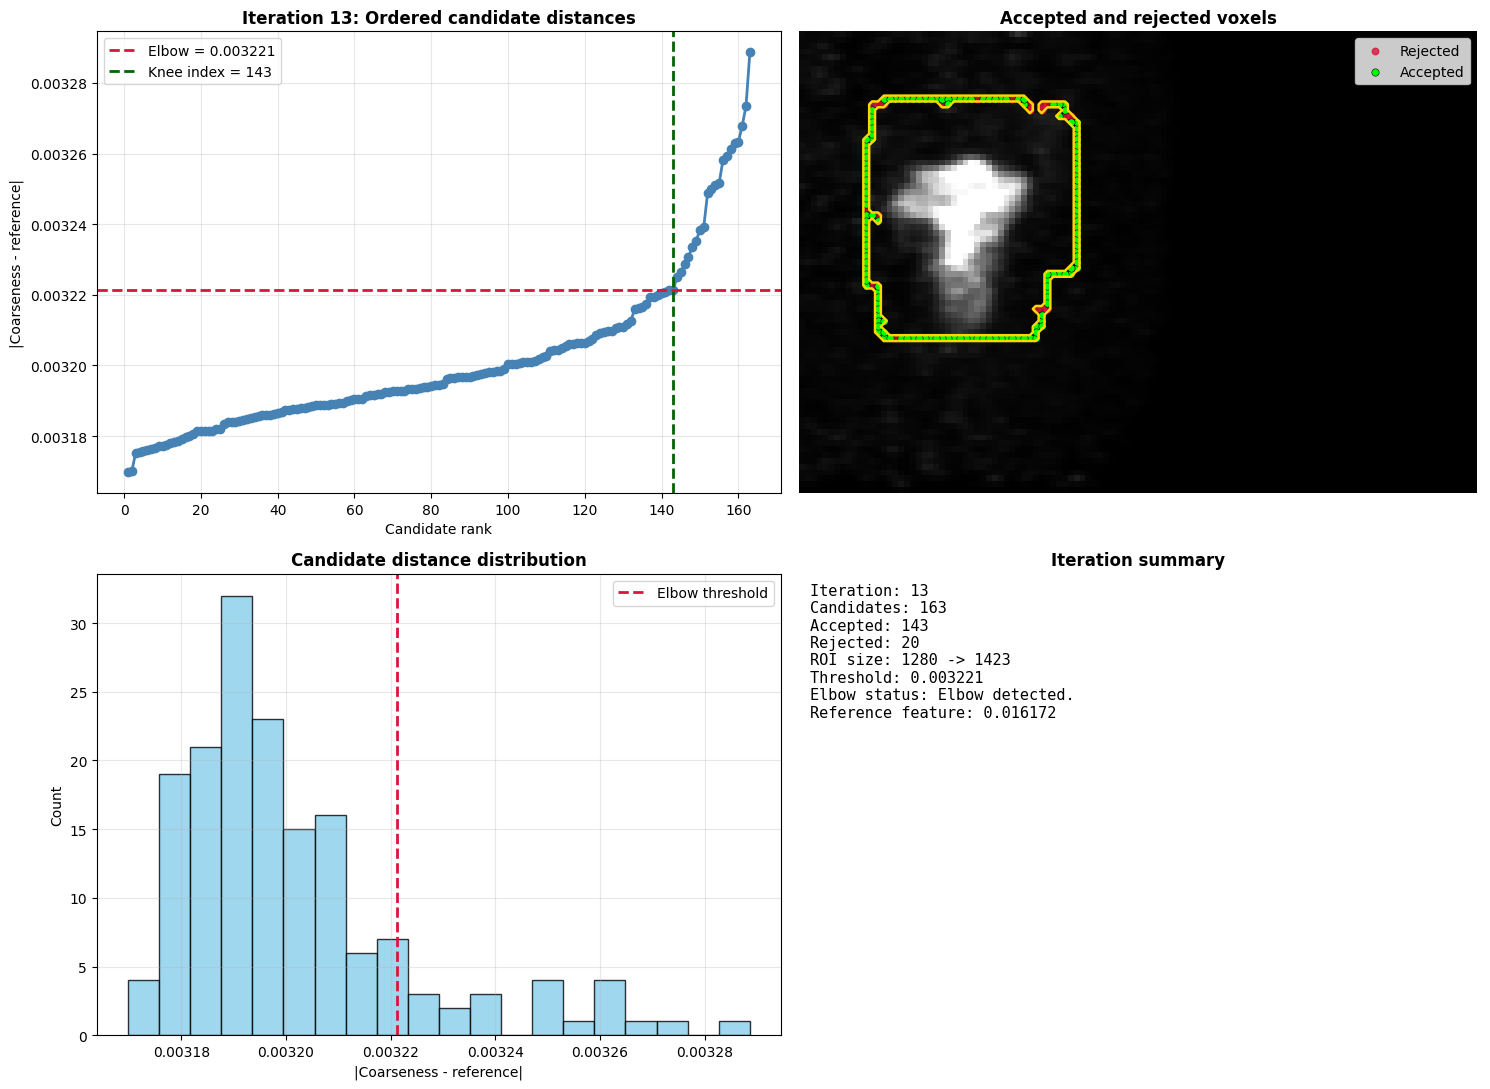

Iter 13: ROI 1280 -> 1423 | Candidates:  163 | Accepted:  143 | Rejected:   20 | Threshold: 0.003221 | Elbow detected.


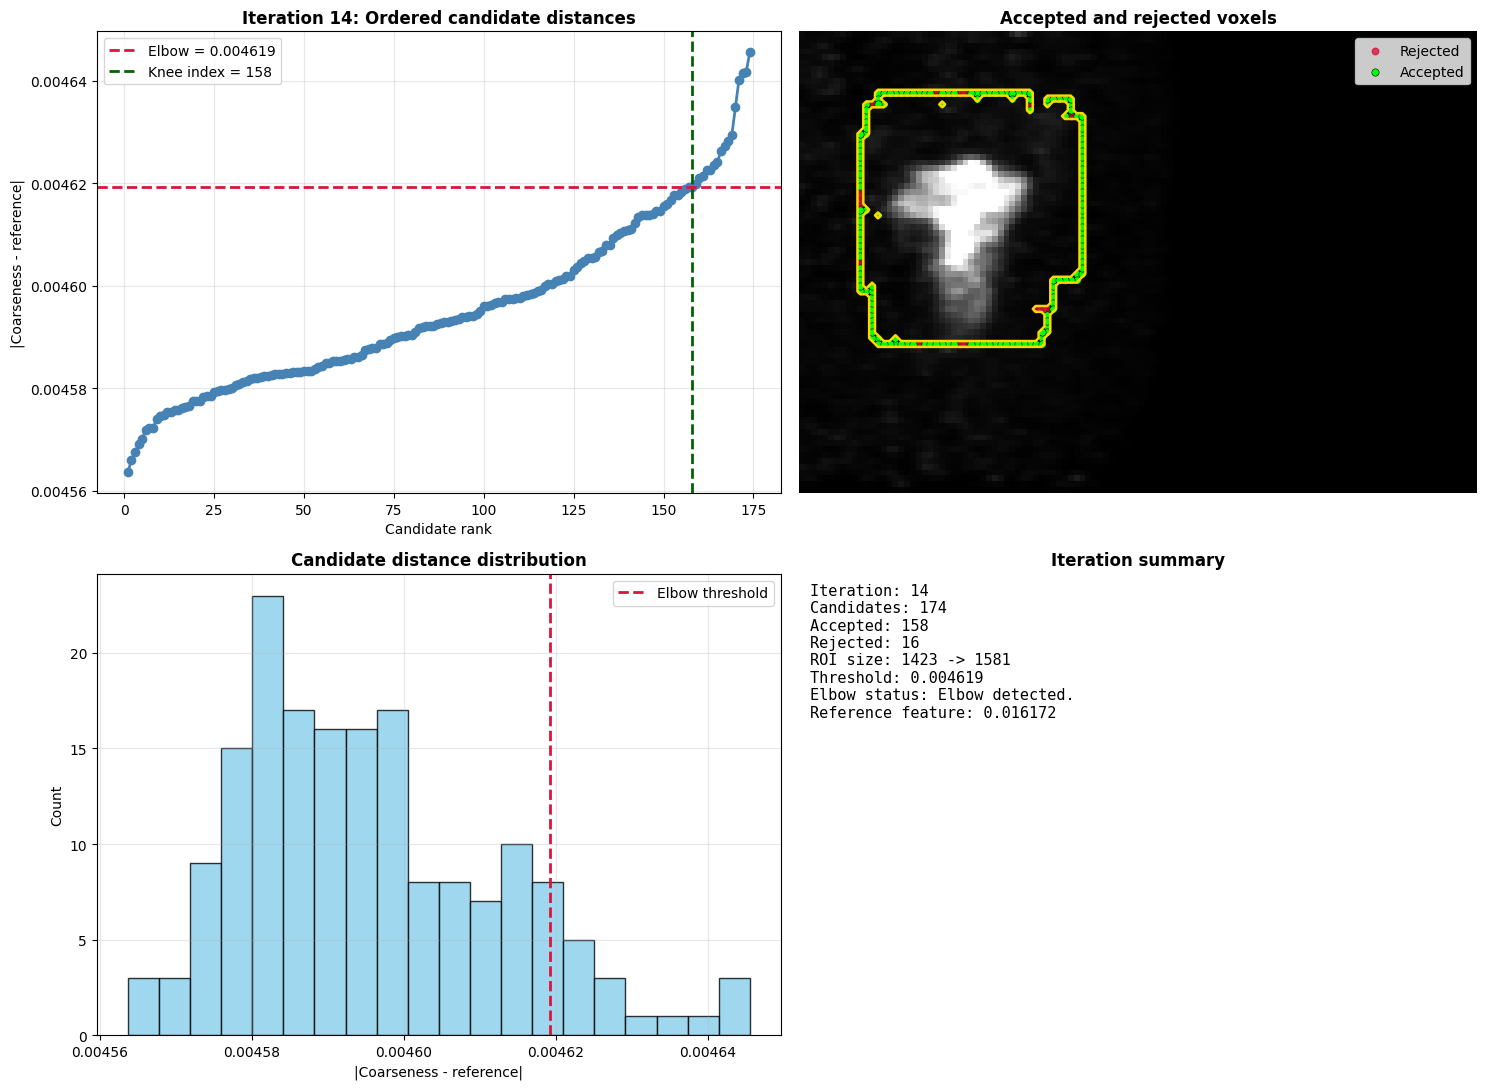

Iter 14: ROI 1423 -> 1581 | Candidates:  174 | Accepted:  158 | Rejected:   16 | Threshold: 0.004619 | Elbow detected.


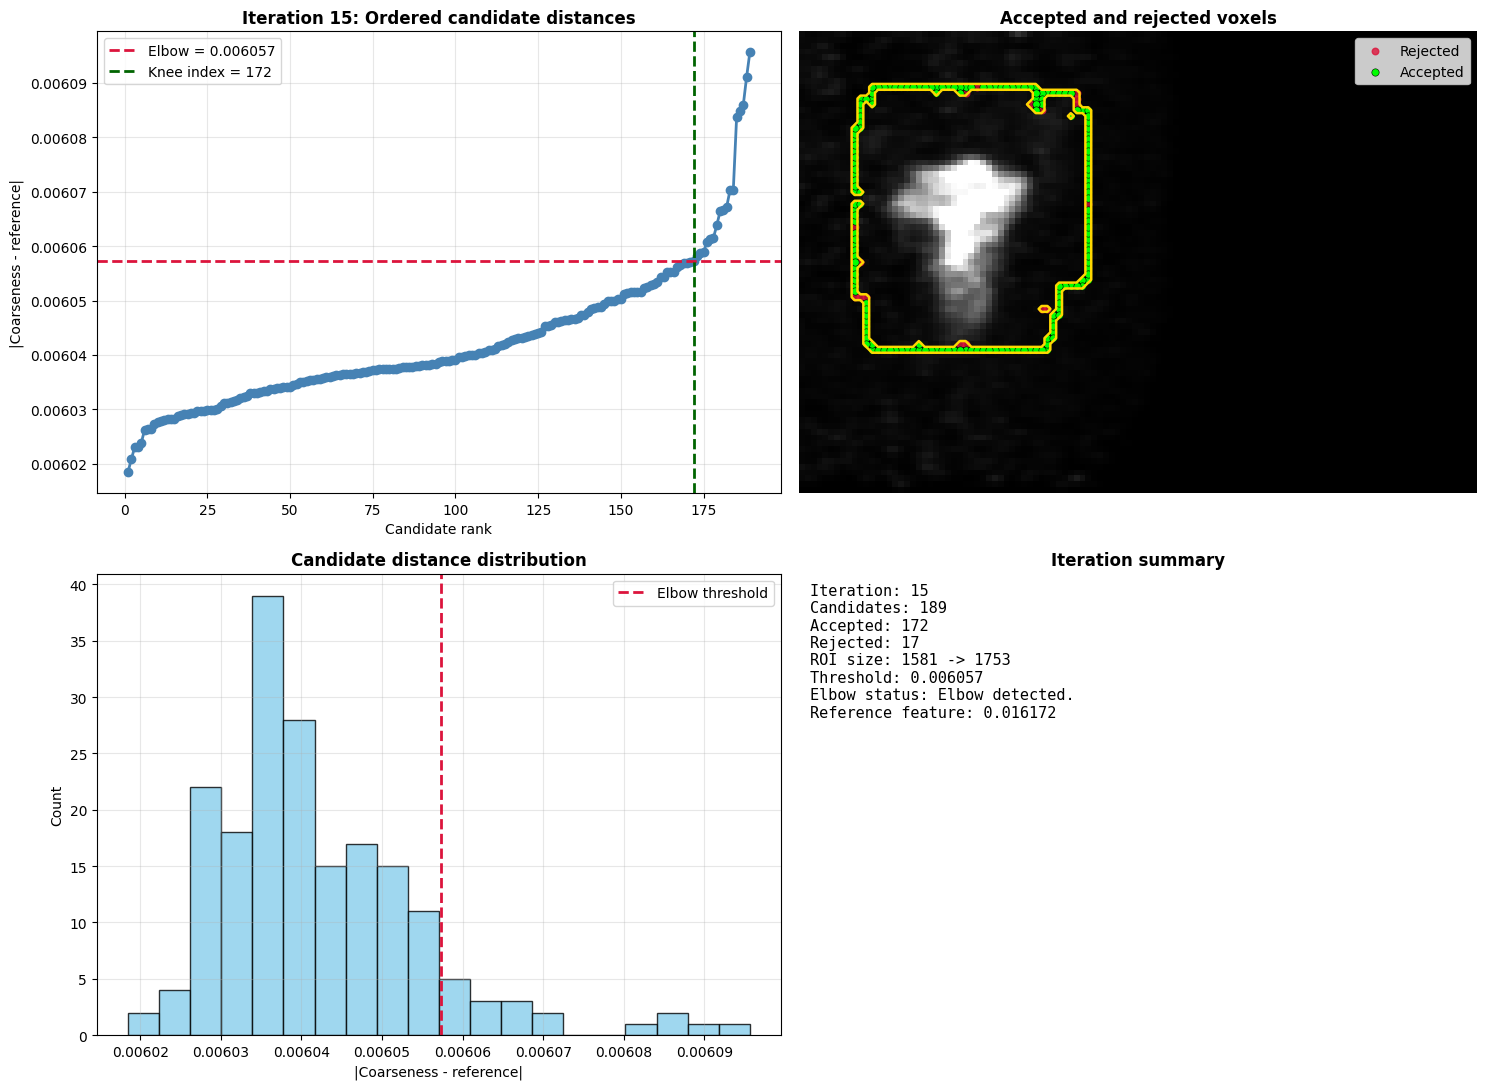

Iter 15: ROI 1581 -> 1753 | Candidates:  189 | Accepted:  172 | Rejected:   17 | Threshold: 0.006057 | Elbow detected.

✓ Iterative region growing completed!
Stopping reason: Maximum number of dilations reached.

Results Summary:
 Iteration  Candidate Voxels  Accepted Voxels  Rejected Voxels  Current ROI Size  New ROI Size  Cumulative Lesion Size  Feature Before  Feature After  Feature Change  Elbow Distance  Elbow Index
         1                75               59               16                76           135                     135        0.016172       0.018544        0.002372        0.000436           59
         2                69               66                3               135           201                     201        0.018544       0.018001       -0.000544        0.002564           66
         3                76               73                3               201           274                     274        0.018001       0.018889        0.000889        0.002013    

In [31]:
def compute_global_feature(mask):
    """
    Compute the global radiomic feature for a given binary ROI.
    """

    mask_3d = mask[np.newaxis, :, :].astype(np.uint8)

    sitk_mask = sitk.GetImageFromArray(mask_3d)

    result = extractor.execute(
        sitk_img,
        sitk_mask,
        voxelBased=False
    )

    feature_value = float(result[FEATURE_KEY])

    return feature_value, result

# Iterative region growing with the elbow-based radiomic strategy
roi_final, results, history, stopping_reason = run_region_growing(reference_feature)

print("\n✓ Iterative region growing completed!")
print(f"Stopping reason: {stopping_reason}")

# Create results DataFrame
df_results = pd.DataFrame(results)
print("\nResults Summary:")
print(df_results.to_string(index=False))

## Stage 6: Results & Visualizations

In [32]:
# Results summary table
print("\n" + "="*80)
print("ITERATIVE REGION GROWING RESULTS")
print("="*80)

df_results = pd.DataFrame(results)
print(df_results.to_string(index=False))
print("="*80)

# Summary statistics
roi_final = history[-1]["roi_after"] if history else mask0.copy()
total_growth = int(roi_final.sum() - mask0.sum())
percent_growth = (total_growth / mask0.sum()) * 100 if mask0.sum() > 0 else np.nan
iterations_run = len(df_results)

print(f"\nFinal Summary:")
print(f"  - Feature: {FEATURE_CLASS}.{FEATURE_NAME}")
print(f"  - Initial ROI0 size: {mask0.sum()} voxels")
print(f"  - Final ROI size: {roi_final.sum()} voxels")
print(f"  - Total voxels added: {total_growth} voxels ({percent_growth:.1f}% growth)")
print(f"  - Iterations executed: {iterations_run}")
print(f"  - Max dilations: {MAX_DILATIONS}")
print(f"  - Stopping reason: {stopping_reason}")
print(f"  - Reference feature: {reference_feature:.6f}")


ITERATIVE REGION GROWING RESULTS
 Iteration  Candidate Voxels  Accepted Voxels  Rejected Voxels  Current ROI Size  New ROI Size  Cumulative Lesion Size  Feature Before  Feature After  Feature Change  Elbow Distance  Elbow Index
         1                75               59               16                76           135                     135        0.016172       0.018544        0.002372        0.000436           59
         2                69               66                3               135           201                     201        0.018544       0.018001       -0.000544        0.002564           66
         3                76               73                3               201           274                     274        0.018001       0.018889        0.000889        0.002013           73
         4                86               82                4               274           356                     356        0.018889       0.020016        0.001127        0.002862     

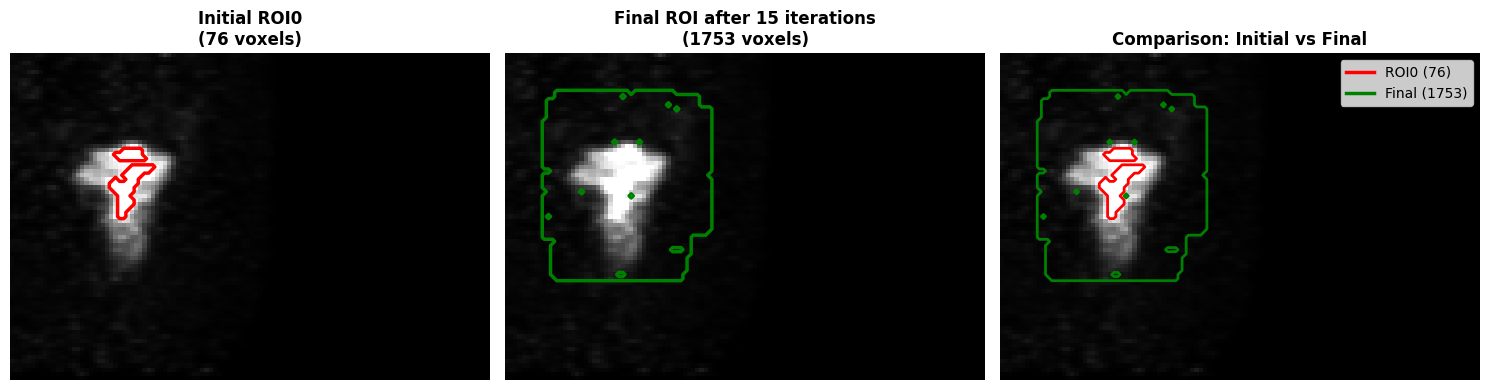

In [33]:
# Visualization: Final ROI evolution
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

final_iteration_count = len(history)
roi_final = history[-1]["roi_after"] if history else mask0.copy()

# Plot 1: Original image with initial mask
axes[0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[0].contour(mask0, colors='r', linewidths=2.5)
axes[0].set_title(f"Initial ROI0\n({mask0.sum()} voxels)", fontsize=12, fontweight='bold')
axes[0].axis('off')

# Plot 2: Original image with final ROI
axes[1].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[1].contour(roi_final, colors='g', linewidths=2.5)
axes[1].set_title(f"Final ROI after {final_iteration_count} iterations\n({roi_final.sum()} voxels)", 
                  fontsize=12, fontweight='bold')
axes[1].axis('off')

# Plot 3: Comparison with overlays
axes[2].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
axes[2].contour(mask0, colors='r', linewidths=2)
axes[2].contour(roi_final, colors='g', linewidths=2)

# Create custom legend
from matplotlib.lines import Line2D
custom_lines = [
    Line2D([0], [0], color='r', lw=2.5),
    Line2D([0], [0], color='g', lw=2.5)
]
axes[2].legend(custom_lines, [f'ROI0 ({mask0.sum()})', f'Final ({roi_final.sum()})'], 
               loc='upper right', fontsize=10)
axes[2].set_title("Comparison: Initial vs Final", fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

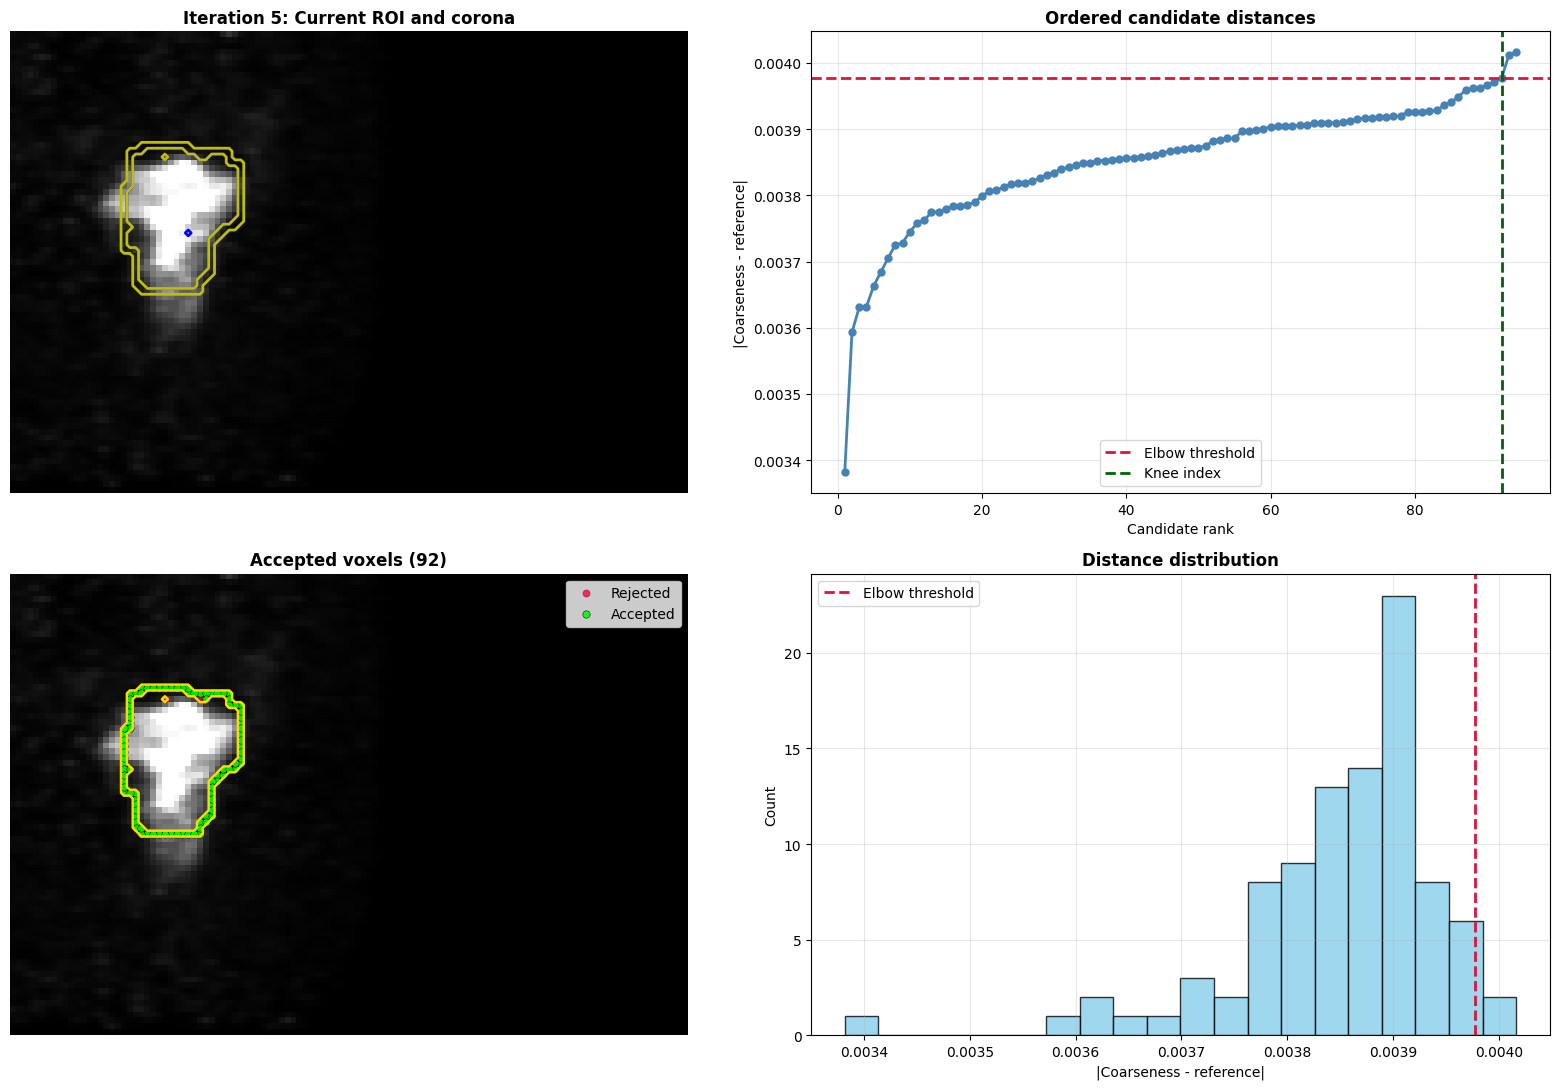

In [34]:
# Detailed visualization of a specific iteration using the elbow-based growth diagnostics
iter_to_show = min(5, len(history))  # Show iteration 5, or last if fewer iterations

if iter_to_show == 0:
    print("No growth iterations were executed.")
else:
    data_iter = history[iter_to_show - 1]

    fig, axes = plt.subplots(2, 2, figsize=(16, 11))

    # Row 1: Iteration details
    axes[0, 0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
    axes[0, 0].contour(data_iter["roi_current"], colors='b', linewidths=2)
    axes[0, 0].contour(data_iter["corona"], colors='y', linewidths=2)
    axes[0, 0].set_title(f"Iteration {iter_to_show}: Current ROI and corona", fontweight='bold')
    axes[0, 0].axis('off')

    axes[0, 1].plot(
        np.arange(1, data_iter["ordered_distances"].size + 1),
        data_iter["ordered_distances"],
        'o-',
        linewidth=2,
        markersize=5,
        color='steelblue'
    )
    if data_iter["elbow_value"] is not None:
        axes[0, 1].axhline(data_iter["elbow_value"], color='crimson', linestyle='--', linewidth=2, label='Elbow threshold')
        axes[0, 1].axvline(data_iter["elbow_index"] + 1, color='darkgreen', linestyle='--', linewidth=2, label='Knee index')
    axes[0, 1].set_title("Ordered candidate distances", fontweight='bold')
    axes[0, 1].set_xlabel("Candidate rank")
    axes[0, 1].set_ylabel(f"|{FEATURE_NAME} - reference|")
    axes[0, 1].grid(alpha=0.3)
    axes[0, 1].legend()

    # Row 2: Accepted/rejected map and summary
    axes[1, 0].imshow(roi_img, cmap="gray", vmin=0, vmax=np.percentile(roi_img, 99))
    axes[1, 0].contour(data_iter["corona"], colors='gold', linewidths=1.8)
    if data_iter["rejected_positions"].size > 0:
        axes[1, 0].scatter(
            data_iter["rejected_positions"][:, 1],
            data_iter["rejected_positions"][:, 0],
            s=22,
            c='crimson',
            alpha=0.8,
            label='Rejected'
        )
    if data_iter["accepted_positions"].size > 0:
        axes[1, 0].scatter(
            data_iter["accepted_positions"][:, 1],
            data_iter["accepted_positions"][:, 0],
            s=28,
            c='lime',
            edgecolors='black',
            linewidths=0.4,
            alpha=0.9,
            label='Accepted'
        )
    axes[1, 0].set_title(f"Accepted voxels ({data_iter['accepted_positions'].shape[0]})", fontweight='bold')
    axes[1, 0].axis('off')
    axes[1, 0].legend(loc='upper right')

    bins = min(20, max(5, data_iter["ordered_distances"].size // 2))
    axes[1, 1].hist(data_iter["ordered_distances"], bins=bins, color='skyblue', edgecolor='k', alpha=0.8)
    if data_iter["elbow_value"] is not None:
        axes[1, 1].axvline(data_iter["elbow_value"], color='crimson', linestyle='--', linewidth=2, label='Elbow threshold')
        axes[1, 1].legend()
    axes[1, 1].set_title("Distance distribution", fontweight='bold')
    axes[1, 1].set_xlabel(f"|{FEATURE_NAME} - reference|")
    axes[1, 1].set_ylabel("Count")
    axes[1, 1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

## Stage 7: Comparison with manual segmentation

In [35]:
# ==============================================================================
# Stage 7.1: Basic Overlap Analysis
# ==============================================================================

manual = manual_mask_roi.astype(bool)
auto = roi_final.astype(bool)

TP = np.logical_and(manual, auto).sum()
FP = np.logical_and(~manual, auto).sum()
FN = np.logical_and(manual, ~auto).sum()
TN = np.logical_and(~manual, ~auto).sum()

print("="*60)
print("OVERLAP ANALYSIS")
print("="*60)

print(f"Manual voxels:     {manual.sum()}")
print(f"Automatic voxels:  {auto.sum()}")

print()
print(f"TP: {TP}")
print(f"FP: {FP}")
print(f"FN: {FN}")
print(f"TN: {TN}")

OVERLAP ANALYSIS
Manual voxels:     318
Automatic voxels:  1753

TP: 317
FP: 1436
FN: 1
TN: 7410


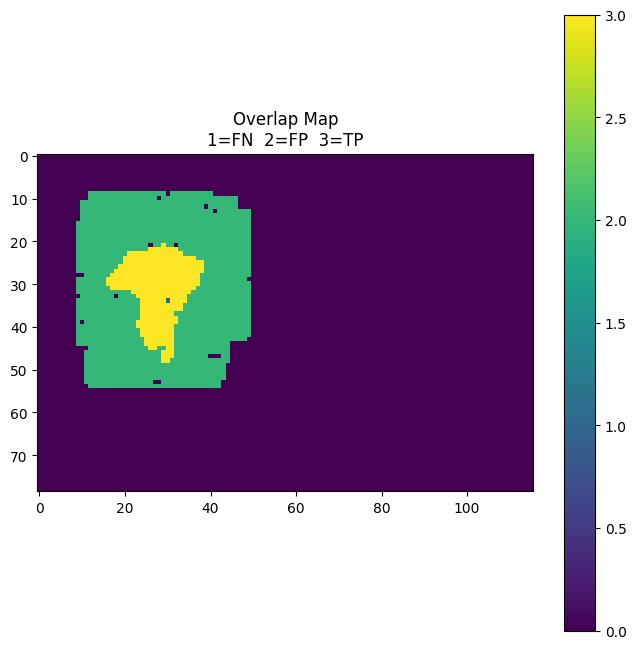

In [36]:
# ==============================================================================
# Visual overlap map
# ==============================================================================

overlap = np.zeros_like(manual, dtype=np.uint8)

overlap[manual & auto] = 3      # TP
overlap[~manual & auto] = 2     # FP
overlap[manual & ~auto] = 1     # FN

plt.figure(figsize=(8,8))

plt.imshow(overlap)

plt.title(
    "Overlap Map\n"
    "1=FN  2=FP  3=TP"
)

plt.colorbar()
plt.show()

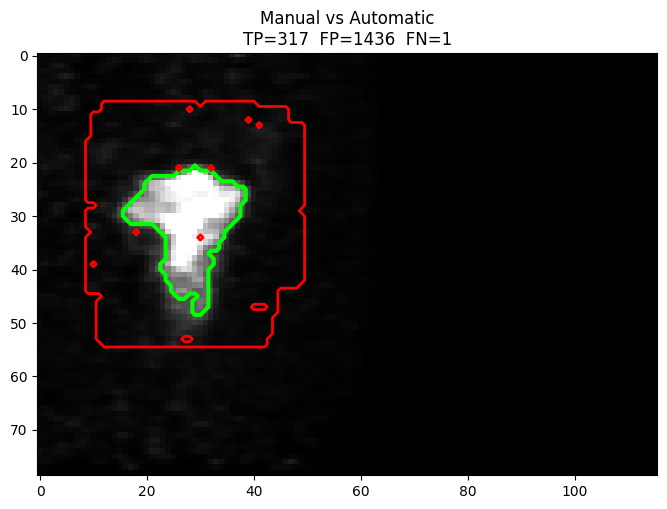

In [37]:
plt.figure(figsize=(8,8))

plt.imshow(
    roi_img,
    cmap="gray",
    vmin=0,
    vmax=np.percentile(roi_img,99)
)

plt.contour(
    manual,
    colors="lime",
    linewidths=3
)

plt.contour(
    auto,
    colors="red",
    linewidths=2
)

plt.title(
    f"Manual vs Automatic\n"
    f"TP={TP}  FP={FP}  FN={FN}"
)

plt.show()

In [38]:

dice = (2 * TP) / (2 * TP + FP + FN)

iou = TP / (TP + FP + FN)

recall = TP / (TP + FN)

precision = TP / (TP + FP)

metrics_df = pd.DataFrame({
    "Metric": [
        "Dice",
        "IoU",
        "Recall",
        "Precision"
    ],
    "Value": [
        dice,
        iou,
        recall,
        precision
    ]
})

print(f"Final Dice coefficient: {dice:.4f}")

metrics_df

Final Dice coefficient: 0.3061


,Metric,Value
0,Dice,0.306132
1,IoU,0.180730
2,Recall,0.996855
3,Precision,0.180833
